In [254]:
from utils import *
from dipole import *
import pickle

In [255]:
import matplotlib as mpl
from lxml import etree

# Load XML, parse points, and create LinearSegmentedColormap
def load_scivis_cmap(xml_file):
    tree = etree.parse(xml_file)
    nodes = tree.findall('.//Point')
    # Normalize positions and get RGB values
    colors = [(float(n.get('r')), float(n.get('g')), float(n.get('b'))) for n in nodes]
    positions = [float(n.get('x')) for n in nodes]
    
    # Create the segmented dictionary
    cdict = {'red': [], 'green': [], 'blue': []}
    for pos, color in zip(positions, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))
        
    return mpl.colors.LinearSegmentedColormap('SciVisColor', cdict)

# Generate cmap object
my_cmap = load_scivis_cmap('2-redy3.xml')


In [295]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib import colors
from matplotlib import cm, ticker

# plotting specifications
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                            AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText

smaller= 12
small = 16
medium = 20
large = 30

params = {'text.usetex' : True,
        'font.size' : small,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=small
plt.rcParams['figure.figsize']=(5,5)
plt.rcParams['axes.formatter.use_mathtext']=True

In [257]:
from collections import Counter
image_dir_search = 'proc/*.fits'
temperatures = []


for image in glob.glob(image_dir_search):
    temp = re.findall('_\d+k',image)[0][1:-1]
    if 'dtph' not in image:
        continue
    # if temp not in temperatures:
   
    temperatures.append(temp)
temperatures_strs = np.array(temperatures)

print(Counter(temperatures_strs))
# temperatures = np.unique(np.sort(temperatures))
temps = np.sort(np.array([int(t) for t in temperatures_strs]))

temperatures = np.unique(temps)
print(temperatures)
goodQuads = [0,1,2,3]
image_dir = 'proc/'
test_temps = temperatures


try:
    with open('dipole_coord_list.pkl','rb') as infile:
        full_dipole_coord_list = pickle.load(infile)
except FileNotFoundError:
    full_dipole_coord_list = getDipoleList2(image_dir,test_temps,goodQuads)
    with open('dipole_coord_list.pkl','wb') as outfile:
        pickle.dump(full_dipole_coord_list,outfile)
# print(f'# of images at {test_temp}',Counter(temperatures_strs)[str(test_temp)])

Counter()
[]


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/455272499.py:7: SyntaxWarning: invalid escape sequence '\d'
  temp = re.findall('_\d+k',image)[0][1:-1]


In [258]:
total = 0
for q in [0,1,2,3]:
    total += len(full_dipole_coord_list[q])
total

try:
    with open('mc_dist.pkl','rb') as infile:
        mcdict = pickle.load(infile)
    montecarlo_hists = mcdict['montecarlo_hists']
    mc_bin_centers = mcdict['mc_bin_centers']
    mc_mean = mcdict['mc_bin_cemc_meannters']
    ci_lower = mcdict['ci_lower']
    ci_upper = mcdict['ci_upper']


except FileNotFoundError:
    mc_bin_centers, mc_mean, ci_lower, ci_upper,montecarlo_hists = monte_carlo_distance_histograms(
    n_points=total//4,
    grid_width=3072,
    grid_height=512,
    num_samples=10000,
    num_bins=100,
    confidence_level=0.90,
    spline_smoothing=0,
    return_spline=False
    )
    mcdict = {}
    mcdict['mc_bin_centers'] = mc_bin_centers
    mcdict['mc_bin_cemc_meannters'] = mc_mean
    mcdict['ci_lower'] = ci_lower
    mcdict['ci_upper'] = ci_upper
    mcdict['montecarlo_hists'] = montecarlo_hists

    with open('mc_dist.pkl','wb') as outfile:
        pickle.dump(mcdict,outfile)







<>:52: SyntaxWarning: invalid escape sequence '\%'
<>:52: SyntaxWarning: invalid escape sequence '\%'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/2309571430.py:52: SyntaxWarning: invalid escape sequence '\%'
  plt.fill_between(mc_bin_centers, ci_lower, ci_upper, color=mccolor, alpha=0.4, label='90\% CI')


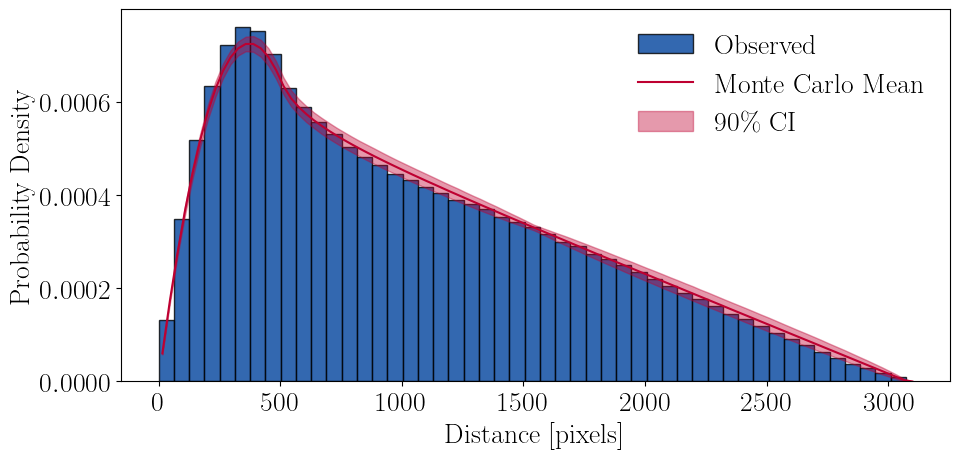

In [259]:
import hist
#analyze spatial distribution here
# 90% confidence interval
plt.figure(figsize=(10,5))
ax = plt.gca()
mccolor = '#be0031'
observed_color = '#00429d'
# plt.plot(mc_bin_centers, spline(mc_bin_centers), label='Spline Fit', color='black', linestyle='--')

from scipy.spatial.distance import pdist
bins_ = np.linspace(0,3072,50)

# all_hists = np.zeros(len(bins_)-1)
all_hists = (
        hist.Hist.new.Reg(50, 0, 3072, name="Distances", label="Distances")
        .Weight()
    )
all_distances = []
for q in [0,1,2,3]:
    quad_dipoles = np.array(full_dipole_coord_list[q])
    distances = pdist(quad_dipoles)
    h_from_data = (
        hist.Hist.new.Reg(50, 0, 3072, name="Distances", label="Distances")
        .Weight()
    )
    h_from_data.fill(distances)
    all_distances.append(distances)

    # hist,bins = np.histogram(distances,bins=bins_,density=False)
    # pdf,bins = np.histogram(distances,bins=bins_,density=True)
    all_hists += h_from_data
    # plt.stairs(pdf,bins,label=f'Quadrant {q+1}')


all_distances = np.concatenate(all_distances)
# bin_widths = np.diff(bins)
# pdf = all_hists / (np.sum(all_hists) * bin_widths)


# h = (
#     hist.Hist.new.Reg(len(counts), bin_edges[0], bin_edges[-1], name="x", label="Value")
#     .Double() # Use Double precision for counts
# )

# mchist,bins = np.histogram(mc_distances,bins=bins)
# mchist = mchist/np.sum(mchist)
# plt.stairs(pdf,bins,label='Observed',lw=3)

# all_hists.plot1d(ax=ax,histtype='fill',density=True,yerr=True,label='Observed',alpha=0.8,color=observed_color)
plt.hist(all_distances,bins_,color=observed_color, edgecolor='black', alpha=0.8,label='Observed',density=True)
plt.plot(mc_bin_centers, mc_mean, label='Monte Carlo Mean', color=mccolor)
plt.fill_between(mc_bin_centers, ci_lower, ci_upper, color=mccolor, alpha=0.4, label='90\% CI')
plt.legend(fontsize=small,frameon=False)
# print(np.max(distances))
# plt.hist(distances)
plt.xlabel('Distance [pixels]',fontsize=small)
plt.ylabel('Probability Density',fontsize=small)
# plt.title('Distribution of Dipoles',fontsize=20)
plt.savefig('figures/trap_distribution.pdf',dpi=300)
plt.show()
plt.close()

In [260]:
try:
    with open('dipole_spectra.pkl','rb') as infile:
        dipole_spectra = pickle.load(infile)
except FileNotFoundError:
    dipole_spectra = getDipoleSpectra2(image_dir,goodQuads,full_dipole_coord_list)
    with open('dipole_spectra.pkl','wb') as outfile:
        pickle.dump(dipole_spectra,outfile)

In [261]:

useIntensityErr = True
wellBehavedThreshold = 4
threshold_str = f'_{wellBehavedThreshold}'
intensity_str = '_err' if useIntensityErr else ''
try:
    with open(f'fit_dipole_spectra{intensity_str}{threshold_str}.pkl','rb') as infile:
        fit_dipole_spectra = pickle.load(infile)

except FileNotFoundError:
    fit_dipole_spectra = fitTrapIntensity(dipole_spectra,useIntensityErr=useIntensityErr,wellBehavedThreshold=wellBehavedThreshold)
    with open(f'fit_dipole_spectra{intensity_str}{threshold_str}.pkl','wb') as outfile:
        pickle.dump(fit_dipole_spectra,outfile)


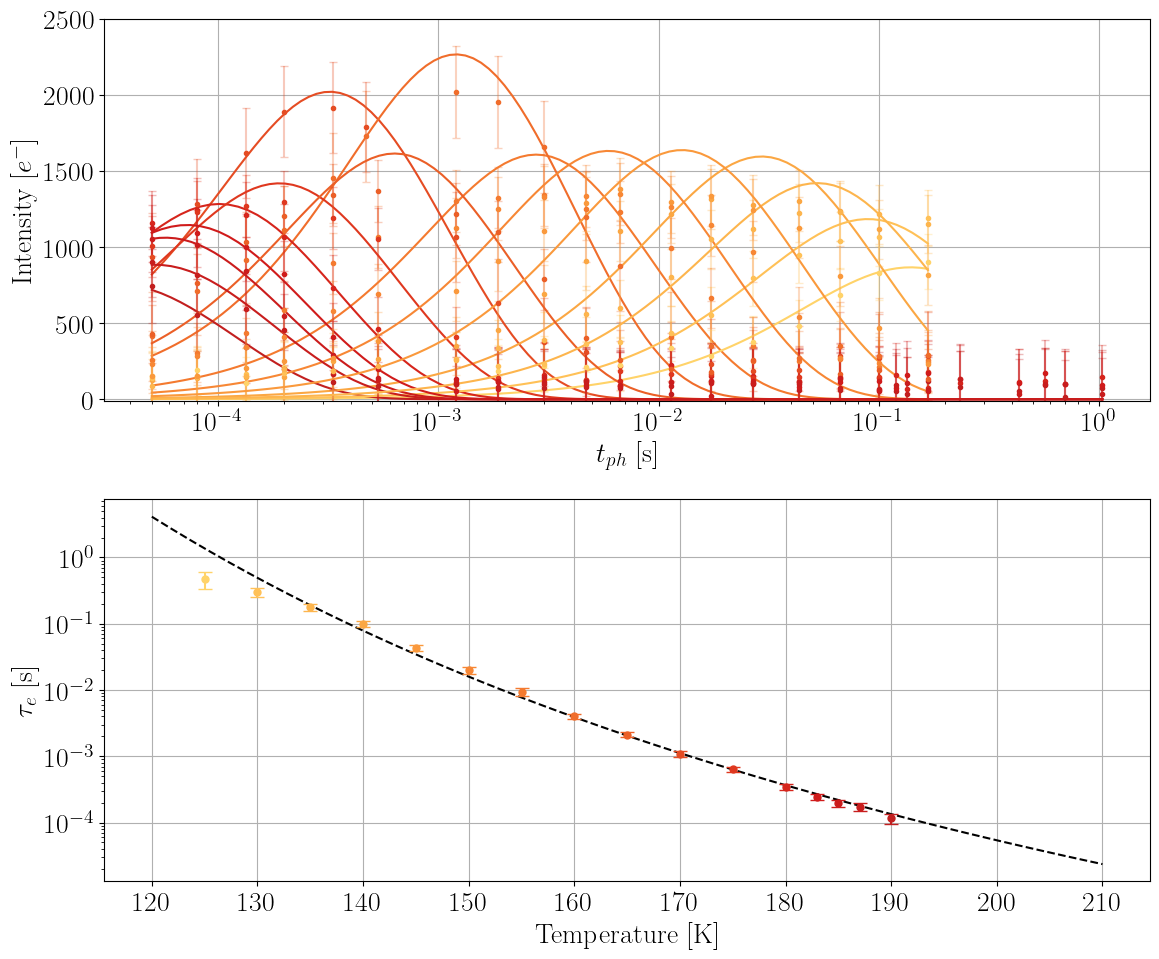

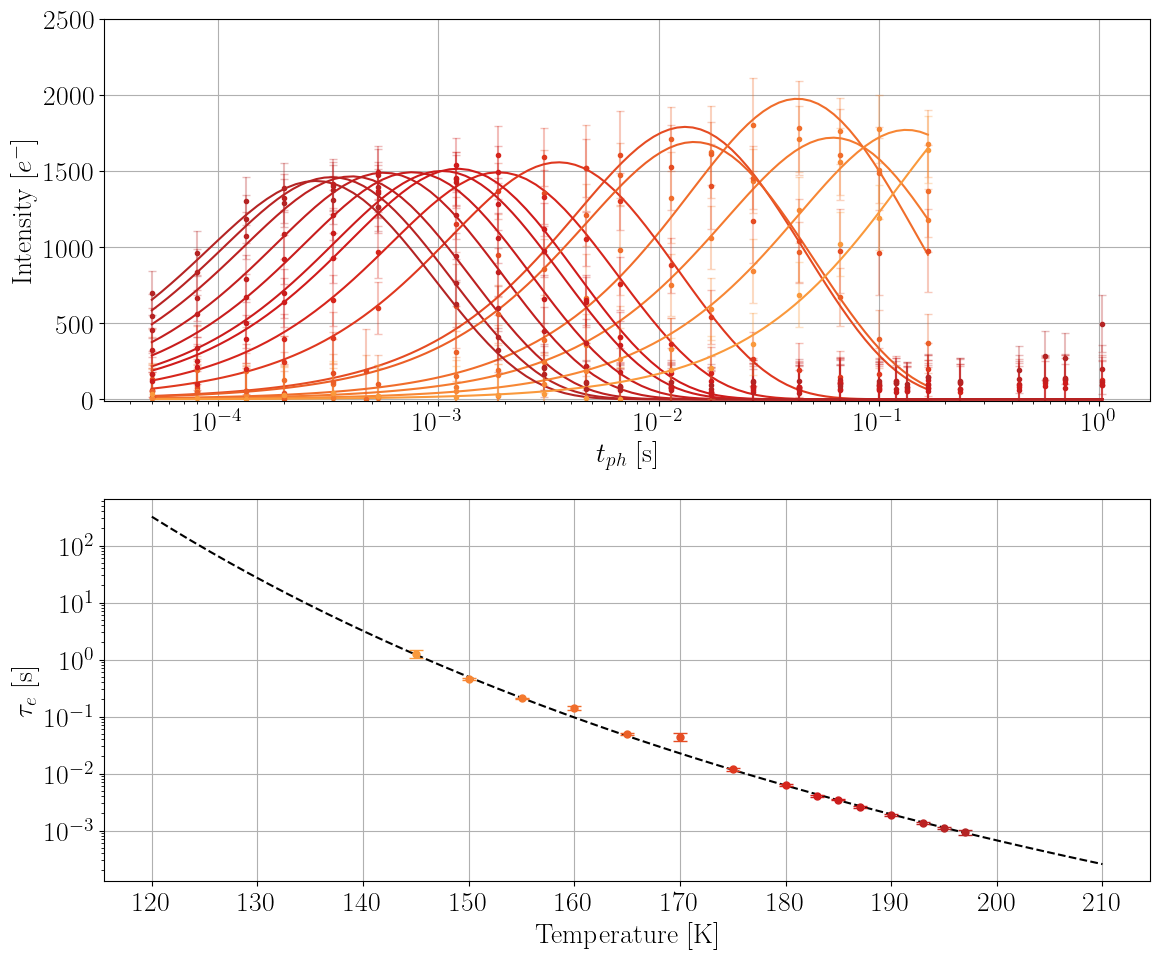

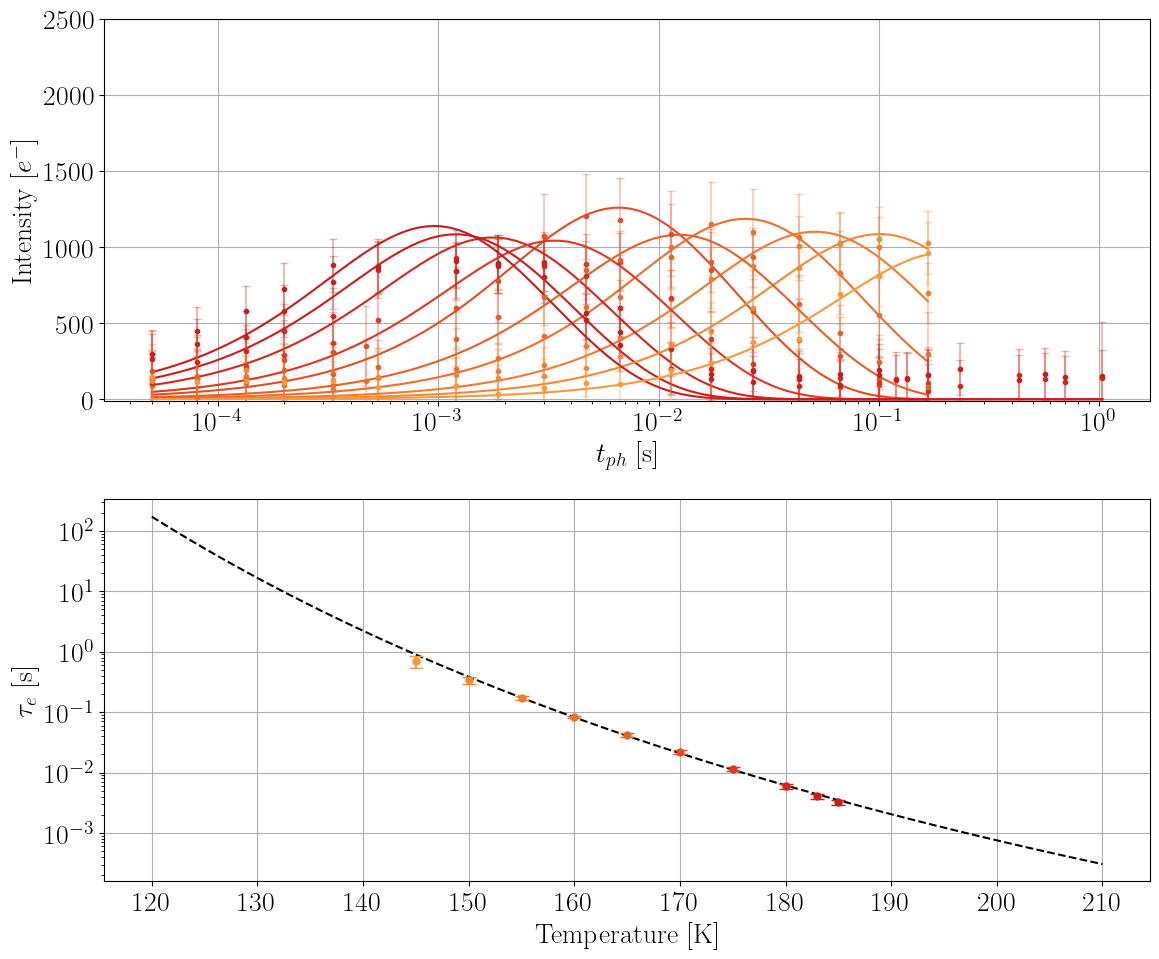

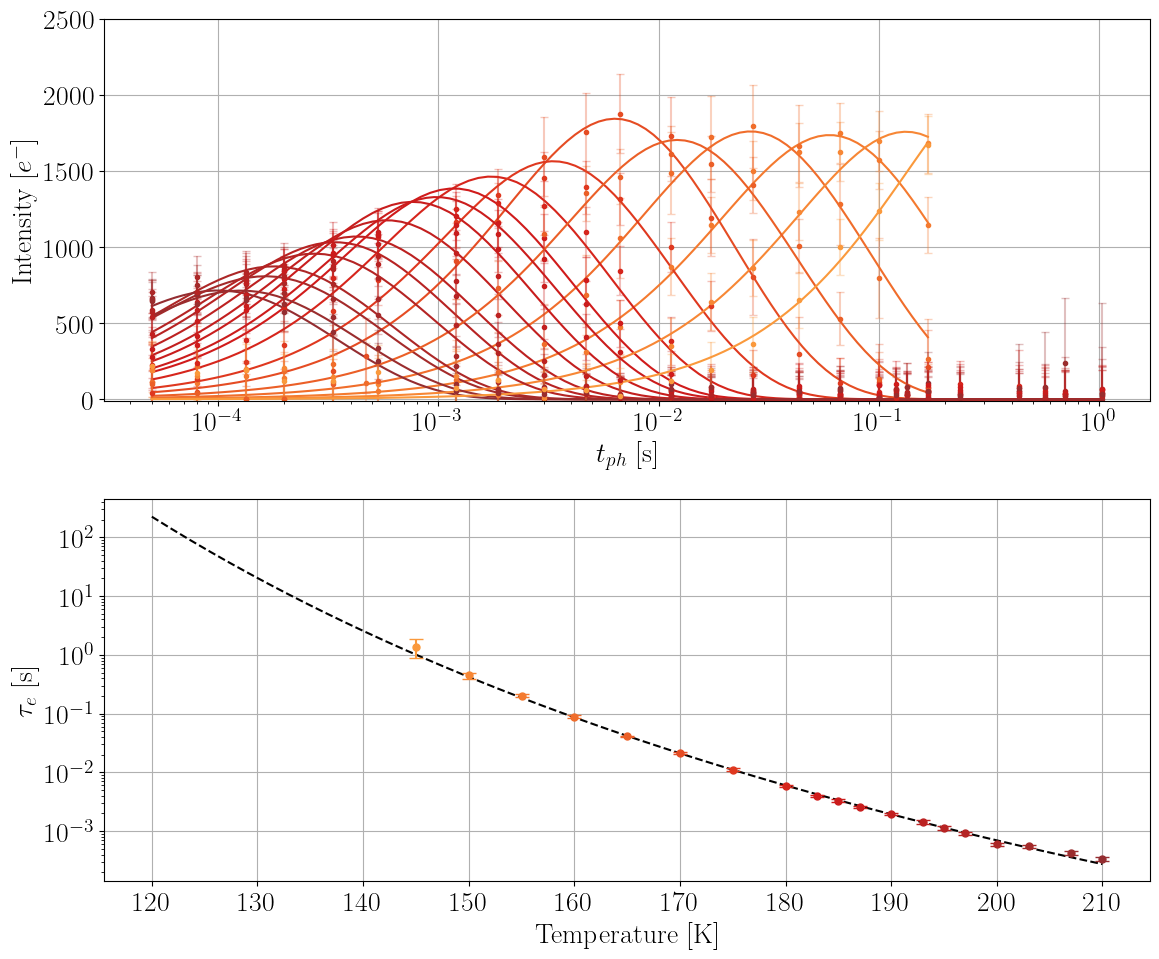

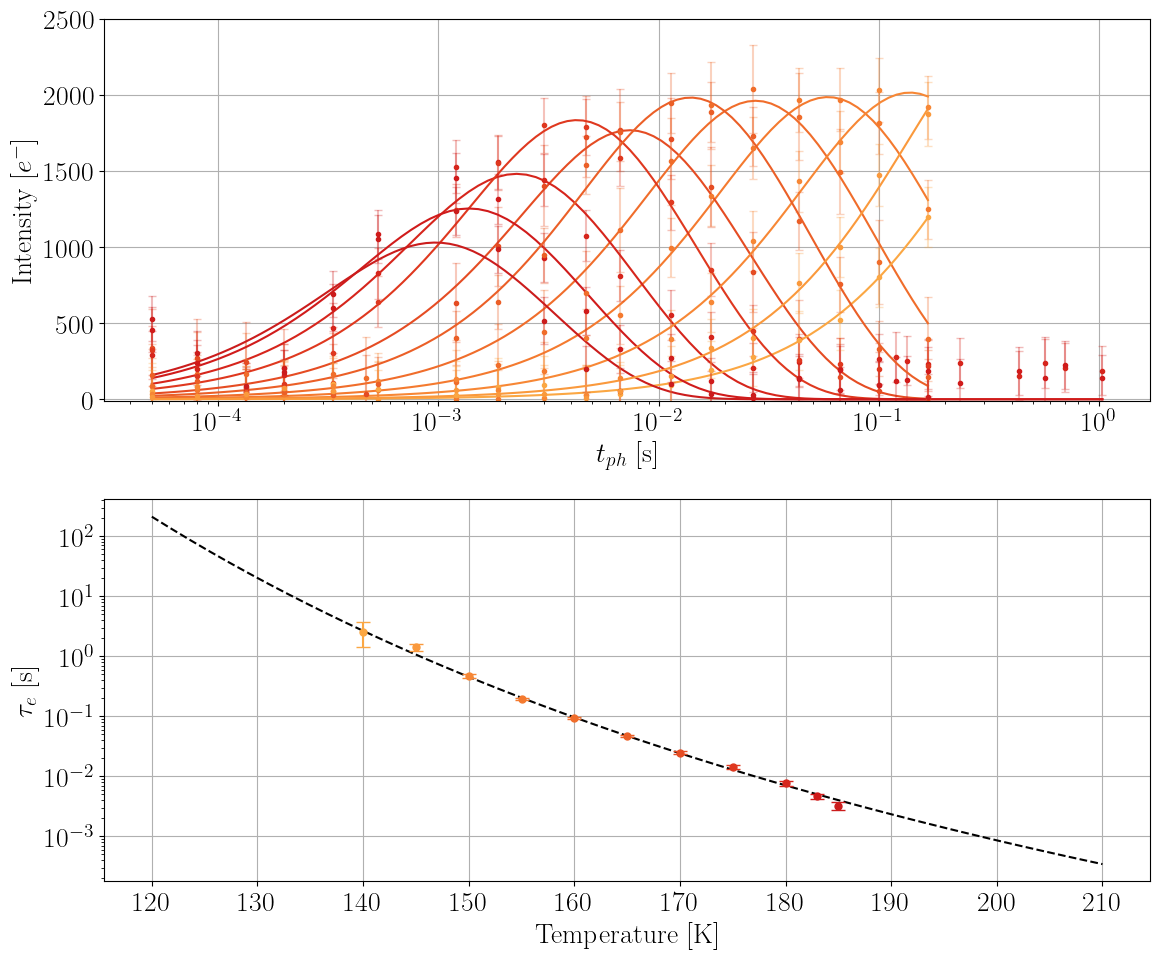

Number of Good Energy Fits Plotted: 
2119


In [286]:
cmap = my_cmap
# cmap = plt.cm.managua_r

import matplotlib.colors as colors
norm = colors.Normalize(vmin=100,vmax=250)

energy_crossSections  = []
tau_temp_fits = []
maxtaus = []
plot = True
max_plots = 5
num_plotted = 0
measurement_temperatures = [125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 183, 185, 187, 190, 193, 195, 197, 200, 203, 207, 210]

tau_temperatures = {

}
for t in measurement_temperatures:
    tau_temperatures[t] = {'measured' : [], 'extrapolated': []}
    
# measured_taus = []
# extrapolated_taus = []
for q in [0,1,2,3]:
    
    dpkeys = list(fit_dipole_spectra[q])
    for i in range(len(dpkeys)):
        

        dp = dpkeys[i]
        if type(dp) != tuple:
            continue
        testdp = fit_dipole_spectra[q][dp]
        if testdp['WellBehavedTrap'] and not testdp['EnergyFitFailed']:
            testdpfit = testdp['EnergyFitInfo']

            p_value = testdpfit['p_value'] 
            chi_squared = testdpfit['chi2']
            r2 = testdpfit['r_squared']


            fit_is_good = chi_squared < 100

            fit_is_good = p_value < 0.05
            fit_is_good = testdp["GoodEnergyFit"]
            # fit_is_good = fit_is_good and 
            maxtau = np.max(testdpfit['taus'])
            maxtaus.append(maxtau)
            # fit_is_good = fit_is_good
            # fit_is_good = True


            if fit_is_good:
                cs = testdpfit['BestFitCrossSection']
                cserr = testdpfit['BestFitCrossSectionErr']
                e = testdpfit['BestFitEnergy']
                e_err = testdpfit['BestFitEnergyErr']

                avg_good_temp = np.mean(testdpfit['temperatures'])

                

                

                # if 135 > np.min(testdpfit['temperatures']) and 135 < np.max(testdpfit['temperatures']):
                for t in measurement_temperatures:
                    logtau = log_energy_cross_section(t,e,np.log(cs))
                    tau = np.exp(logtau)
                    
                    if t in testdpfit['temperatures']:
                        tau_temperatures[t]['measured'].append(tau)
                    else:
                        tau_temperatures[t]['extrapolated'].append(tau)



                # if 135 in testdpfit['temperatures']:
                #     measured_taus.append(tau_at_135)
                # else:
                #     extrapolated_taus.append(tau_at_135)
                
                #uncheck this to filter

                # if 135 not in testdp.keys():
                #     continue

                pcov = testdpfit['CovarianceMatrix']
                perr1 = cserr / cs
                perr = np.array([testdpfit['BestFitEnergyErr'],perr1])
                corr_matrix = pcov / np.outer(perr, perr)
                avg_corr = (corr_matrix[0,1] + corr_matrix[1,0])/2
                # if testdp["GoodEnergyFit"]:
                energy_crossSections.append((cs,e,cserr,e_err,avg_good_temp))
                tau_temp_fits.append([testdpfit['temperatures'],testdpfit['taus'],testdpfit['tau_errs']])
                
        
                    
                    
                if plot and num_plotted < max_plots and len(testdpfit['taus']) > 8:
                    num_plotted +=1
                    fig, ax = plt.subplots(2,1,figsize=(12,10))
                    # fig.suptitle(f"Dipole at {int(dp[0]),int(dp[1])} Quad {q+1}",fontsize=large,y=0.94)
                    ax[0].set_xlabel('$t_{ph}$ [s]',fontsize=small)
                    ax[0].set_ylabel('Intensity [$e^-$]',fontsize=small)

                    ax[1].set_xlabel('Temperature [K]',fontsize=small)
                    ax[1].set_ylabel('$\\tau_e$ [s]',fontsize=small)
                    ax[1].set_xticks([120,130,140,150,160,170,180,190,200,210])
                    ax[0].set_xscale('log')
                    ax[1].set_yscale('log')

                    ax[0].set_ylim(-10,2500)

                    for temp in testdp.keys():
                        if type(temp) != int:
                            continue

                        color = cmap(norm(temp))
                        dipole = testdp[temp]
                        if dipole['GoodIntensityFit']:
                            sigma_image = dipole['image_sigma']
                            
                            # ax[0].scatter(dipole['seconds'],dipole['intensities'],color=color)

                            yerr = dipole['intensity_err'] if useIntensityErr else dipole['poisson_err']

                            # if useIntensityErr:
                            # line, caps, bars = ax[1].errorbar(data[0],data[1],yerr=data[3],ls='None',color=color,capsize=3,marker='o',markersize=4)
                            line, caps, bars = ax[0].errorbar(dipole['seconds'],dipole['intensities'],yerr=yerr,color=color,ls='None',capsize=3,marker='o',markersize=3)
                            for cap in caps:
                                cap.set_alpha(0.3)
                            for bar in bars:
                                bar.set_alpha(0.3)
                            # else:
                                # ax[0].errorbar(dipole['seconds'],dipole['intensities'],yerr=dipole['poisson_err'],color=color,ls='None')

                            seconds = np.geomspace(np.min(dipole['seconds']),np.max(dipole['seconds']),100)
                            fit_ints = intensity_function(seconds,dipole['IntensityFitInfo']['fit_coeff'],dipole['IntensityFitInfo']['fit_tau'])
                            ax[0].plot(seconds,fit_ints,ls='-',color=cmap(norm(temp)))
                            

                    
                    
                    


                    



                    temperatures = np.linspace(120,210,50)
                    log_fit_taus = log_energy_cross_section(temperatures,testdpfit['BestFitEnergy'],np.log(testdpfit['BestFitCrossSection']))
                    fit_taus = np.exp(log_fit_taus)
                    ax[1].plot(temperatures,fit_taus,color='black',ls='--')
                    for t in range(len(testdpfit['temperatures'])):
                        temp = testdpfit['temperatures'][t]
                        color = cmap(norm(temp))
                        tau = testdpfit['taus'][t]
        
                        # ax[1].scatter(temp,tau,color=color)
                        tau_err = testdpfit['tau_errs'][t]

                        ax[1].errorbar(temp,tau,yerr=tau_err,ls='None',color=color,marker='o',markersize=5,capsize=5)
                    # import matplotlib.cm as cmx
                    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
                    # sm.set_array([])  # Required for ScalarMappable to work correctly
                    # cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
                    # cbar = fig.colorbar(sm, cax=cbar_ax)
                    
                    # cbar.set_label('Temperature [K]',fontsize=12)
                    # plt.tight_layout()
                    ax[0].grid()
                    ax[1].grid()
                    plt.savefig(f'figures/example_trap_{num_plotted-1}.pdf',dpi=300)

                    plt.show()
                    plt.close()
                










print("Number of Good Energy Fits Plotted: ")
print(len(energy_crossSections))


<>:97: SyntaxWarning: invalid escape sequence '\s'
<>:102: SyntaxWarning: invalid escape sequence '\s'
<>:97: SyntaxWarning: invalid escape sequence '\s'
<>:102: SyntaxWarning: invalid escape sequence '\s'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/2954136114.py:97: SyntaxWarning: invalid escape sequence '\s'
  ax[1].set_xlabel("$\sigma$ [cm$^2$]",fontsize=small)
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/2954136114.py:102: SyntaxWarning: invalid escape sequence '\s'
  ax[1].set_xlabel("$\sigma$ [cm$^2$]",fontsize=small)


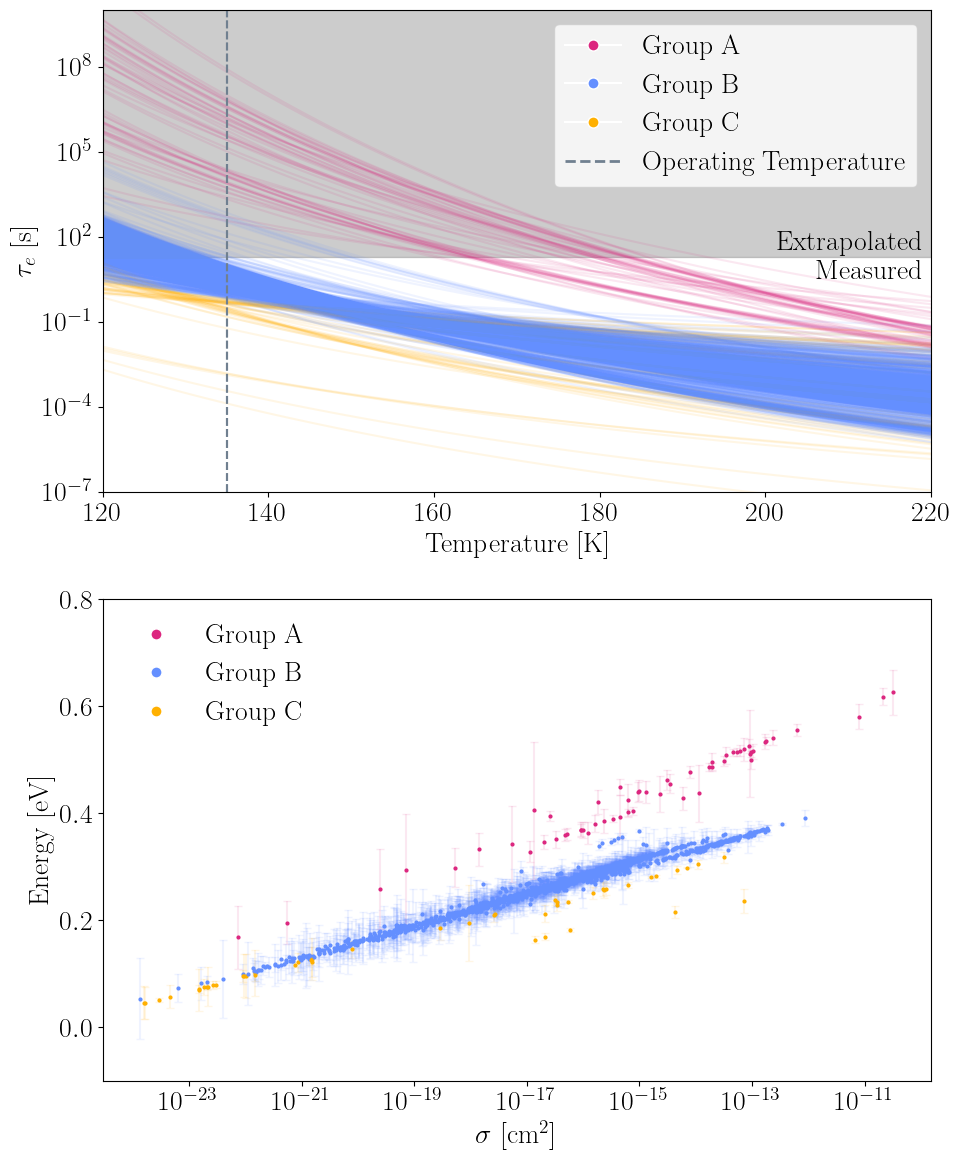

In [270]:
max_tau = 0
for t in range(len(tau_temp_fits)):
    tau = tau_temp_fits[t][1]
    if max_tau < np.max(tau):
        max_tau = np.max(tau)


fig, ax= plt.subplots(2,figsize=(10,12))
fit_temp = np.linspace(120,220,100)

cmap = plt.cm.plasma
cross_sections = np.array(energy_crossSections)[:,0]
log_cross_sections = np.log(cross_sections)


#decision_boundary
# m = 0.014  
# b = 0.85 
T = 170 #histogram
kb = 8.6717333262e-5
m =  (kb*T)
tau_test = 1
# tau_test = 0.00002
# np.log(0.00002)
b = m * (np.log(tau_test) - (-68.267 ) + 2 * np.log(m))


T2 = 130
m2 =  (kb*T2)
b2 = m2 * (np.log(tau_test) - (-68.267 ) + 2 * np.log(m2))

# plt.plot(x_vals, m * x_vals + b, linestyle='--', label=f'{T}K')




avg_A = []
avg_B = []
avg_C = []

# print(len(energies),len(energy_crossSections))
norm = colors.LogNorm(vmin=np.min(cross_sections),vmax=np.max(cross_sections))
for d,data in enumerate(energy_crossSections):
    temperatures = tau_temp_fits[d][0]
    taus = tau_temp_fits[d][1]
    tau_errs = tau_temp_fits[d][2]
    energy = data[1]
    cs = data[0]
    avgtemp = data[4]
    if energy > (m * np.log(cs) + b):
        color ='#DC267F'
        # color ='c'
        avg_A.append(avgtemp)
    elif energy < (m2 * np.log(cs) + b2):
        color = '#FFB000'
        # color = 'm'
        avg_C.append(avgtemp)
    else:
        color = '#648FFF'

        # color = 'y'
        avg_B.append(avgtemp)


    # color = cmap(d)
    # color = cmap(norm(cs))

    log_tau_fit = log_energy_cross_section(fit_temp,data[1],np.log(data[0]))
    tau_fit = np.exp(log_tau_fit)
    ax[0].plot(fit_temp,tau_fit,color=color,alpha=0.1)
    # ax[0].scatter(temperatures,taus,color=color,s=9)
    # ax[0].errorbar(temperatures,taus,yerr=tau_errs,color=color,ls="None",capsize=1)
    # ax[1].scatter(data[0],data[1],color=color,s=9)
    # ax[1].errorbar(data[0],data[1],xerr=data[2],yerr=data[3],ls='None',color='slategrey',alpha=0.1,capsize=3)
 
    
    line, caps, bars = ax[1].errorbar(data[0],data[1],yerr=data[3],ls='None',color=color,capsize=3,marker='o',markersize=2)
    for bar in bars:
        bar.set_alpha(0.1)

    for cap in caps:
        cap.set_alpha(0.1)


ax[0].text(219,3.16e1,"Extrapolated",fontsize=small,ha='right')
ax[0].text(219,3.16,"Measured",fontsize=small,ha='right')

ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[0].fill_between(fit_temp,np.ones_like(fit_temp)*max_tau,np.ones_like(fit_temp)*1e10,color='grey',alpha=0.4)
ax[0].set_ylim(1e-7,1e10)
ax[0].set_xlim(120,220)

ax[0].set_xlabel("Temperature [K]",fontsize=small)
ax[0].set_ylabel("$\\tau_e$ [s]",fontsize=small)

ax[1].set_xlabel("$\sigma$ [cm$^2$]",fontsize=small)
ax[1].set_ylabel("Energy [eV]",fontsize=small)
ax[1].set_ylim(-0.1,0.8)
ax[0].axvline(135,ls='--',label='Operating Temperature',color='slategrey')

ax[1].set_xlabel("$\sigma$ [cm$^2$]",fontsize=small)
ax[1].set_ylabel("Energy [eV]",fontsize=small)
ax[1].set_ylim(-0.1,0.8)
ax[0].axvline(135,ls='--',label='Operating Temperature',color='slategrey')

# --- Add this block to create and display custom legend handles ---
custom_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#DC267F', markersize=8, label='Group A'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#648FFF', markersize=8, label='Group B'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFB000', markersize=8, label='Group C'),
    Line2D([0], [0], linestyle='--', color='slategrey', lw=2, label='Operating Temperature')

]

custom_handles2 = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#DC267F', markersize=8, label='Group A'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#648FFF', markersize=8, label='Group B'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFB000', markersize=8, label='Group C'),

]
# custom_handles = custom_handles +  obs_handle
# Add the legend to the bottom plot (ax[1])
ax[0].legend(handles=custom_handles, loc='best', fontsize=small)
ax[1].legend(handles=custom_handles2, loc='best', fontsize=small,frameon=False)
# --

# fig.suptitle("Characterized Charge Traps",fontsize=24,y=0.92)
# plt.tight_layout()
# sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])  # Required for ScalarMappable to work correctly
# cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
# cbar = fig.colorbar(sm, cax=cbar_ax)
# cbar.set_label('$\sigma$ [cm$^2$]',fontsize=16)
plt.savefig('figures/characterized_traps.pdf',dpi=300)

plt.show()
plt.close()

In [292]:
# import hist
# from hist import Hist
# # fig,ax = plt.subplots(1,2,figsize=(14,6))

# for t in tau_temperatures.keys():
#     fig = plt.figure(figsize=(8,6))
#     ax = plt.gca()
#     measured_taus = tau_temperatures[t]['measured']
#     extrapolated_taus = tau_temperatures[t]['extrapolated']
    
#     print(len(measured_taus))
#     print(len(extrapolated_taus))
#     minbin = np.min([np.min(measured_taus),np.min(extrapolated_taus)])
#     maxbin = np.max([np.max(measured_taus),np.max(extrapolated_taus)])

#     bins = np.geomspace(1e-5,1e8,100)

#     # mhist= Hist.new.Log(200, minbin, maxbin, name="Measured Emission Times").Weight()
#     # ehist= Hist.new.Log(200, minbin, maxbin, name="Extrapolated Emission Times").Weight()

#     # mhist.fill(measured_taus)
#     # ehist.fill(extrapolated_taus)

#     # mhist,mbins = np.histogram(measured_taus,bins=bins)
#     # ehist,ebins = np.histogram(extrapolated_taus,bins=bins)

#     # plt.stairs(mhist,mbins,color='blue',label='measured',lw=2)
#     # plt.stairs(ehist,ebins,color='grey',label='extrapolated',lw=2)
#     # mhist.plot1d(ax=ax[0],histtype='fill',yerr=False)
#     # ehist.plot1d(ax=ax[1],histtype='fill',yerr=False)


#     # ax.hist(measured_taus+extrapolated_taus, bins, color='slategrey', edgecolor='black', alpha=1,label='Total')
#     ax.hist(extrapolated_taus, bins, color='steelblue', edgecolor='black', alpha=0.8,label='Extrapolated')
#     ax.hist(measured_taus, bins, color='seagreen', edgecolor='black', alpha=0.8,label='Measured')


#     # ax.legend(fontsize=16)
#     ax.set_title(f"Emission $\\tau_e$ of CCD Traps at {t}k",fontsize=20)
#     # ax[1].set_title("Extrapolated Emission $\\tau_e$ of CCD Traps at 135k",fontsize=20)
#     # for a in ax:
#     ax.set_xlabel('$\\tau_e$ [s]',fontsize=16)
#     ax.set_ylabel("\# of Traps",fontsize=16)
#     ax.set_xscale('log')
#     # ax.set_yscale('log')
#     # ax.set_ylim(0,500)
#     # ax[0].set_ylim(0,50)
#     plt.axvline(3600,label='1h',ls='--',color='slategrey')
#     plt.axvline(3600*24,label='1 day',ls='-.',color='slategrey')
#     plt.axvline(3600*24*365,label='1 year',ls=':',color='slategrey')
#     ax.legend(frameon=False)
#     # plt.savefig('figures/tau_at_135k_hist.pdf',dpi=300)
#     plt.show()
#     plt.close()

<>:30: SyntaxWarning: invalid escape sequence '\#'
<>:30: SyntaxWarning: invalid escape sequence '\#'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/3380325883.py:30: SyntaxWarning: invalid escape sequence '\#'
  ax_hist.set_ylabel("\# of Traps", fontsize=16)


Temperature: 125K | Measured: 20 | Extrapolated: 2099


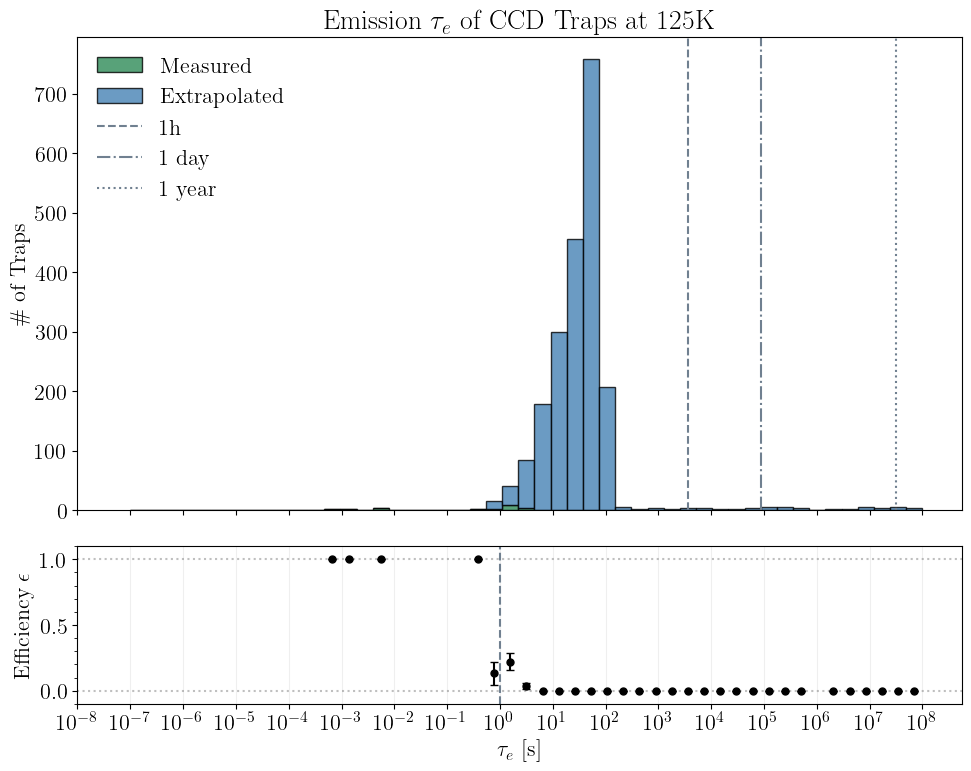

Temperature: 130K | Measured: 35 | Extrapolated: 2084


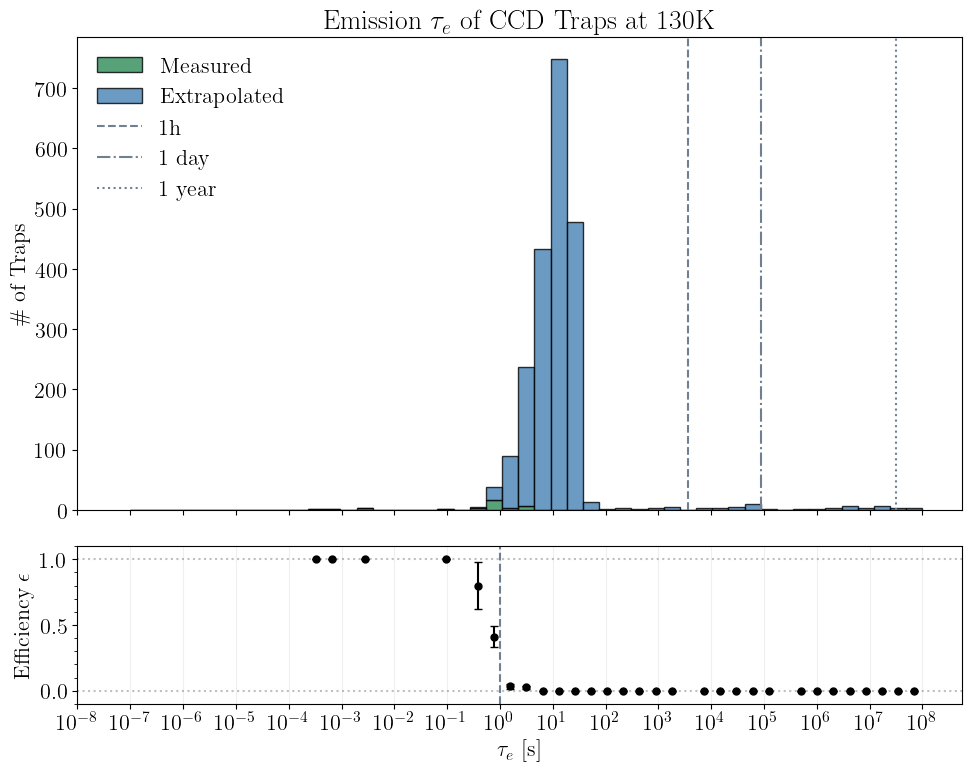

Temperature: 135K | Measured: 292 | Extrapolated: 1827


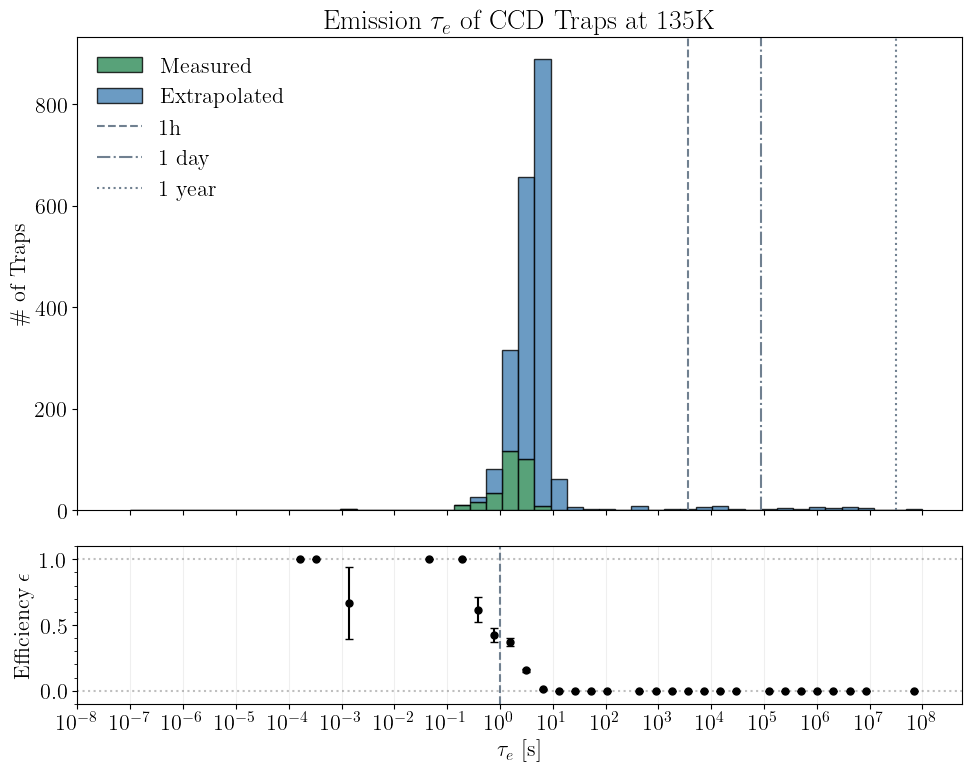

Temperature: 140K | Measured: 1178 | Extrapolated: 941


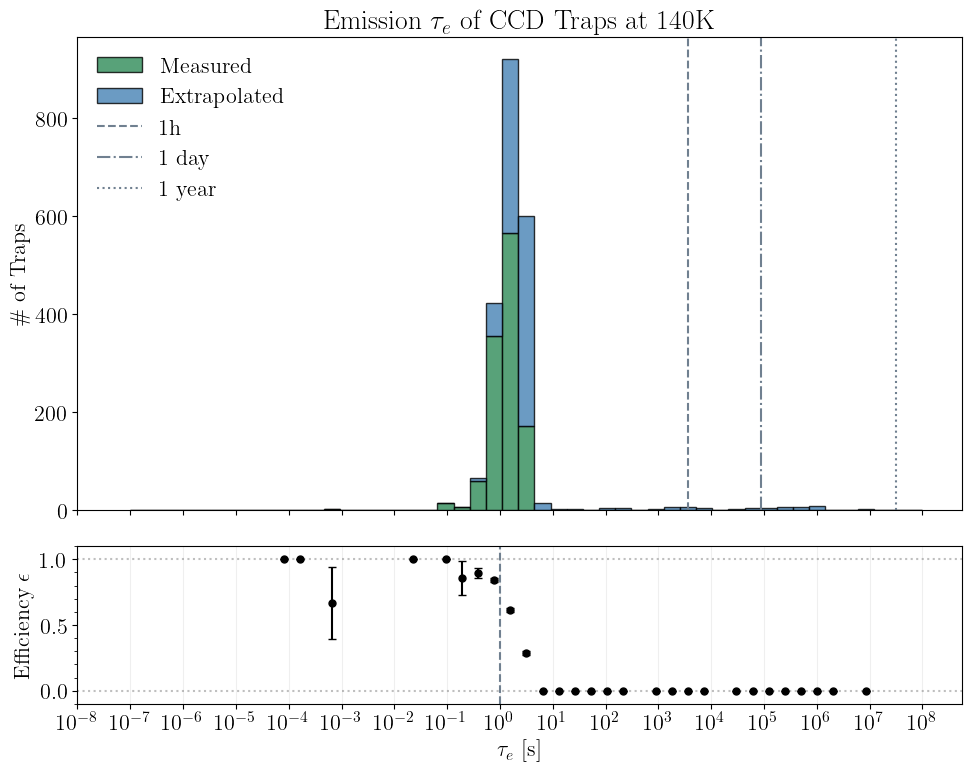

Temperature: 145K | Measured: 1901 | Extrapolated: 218


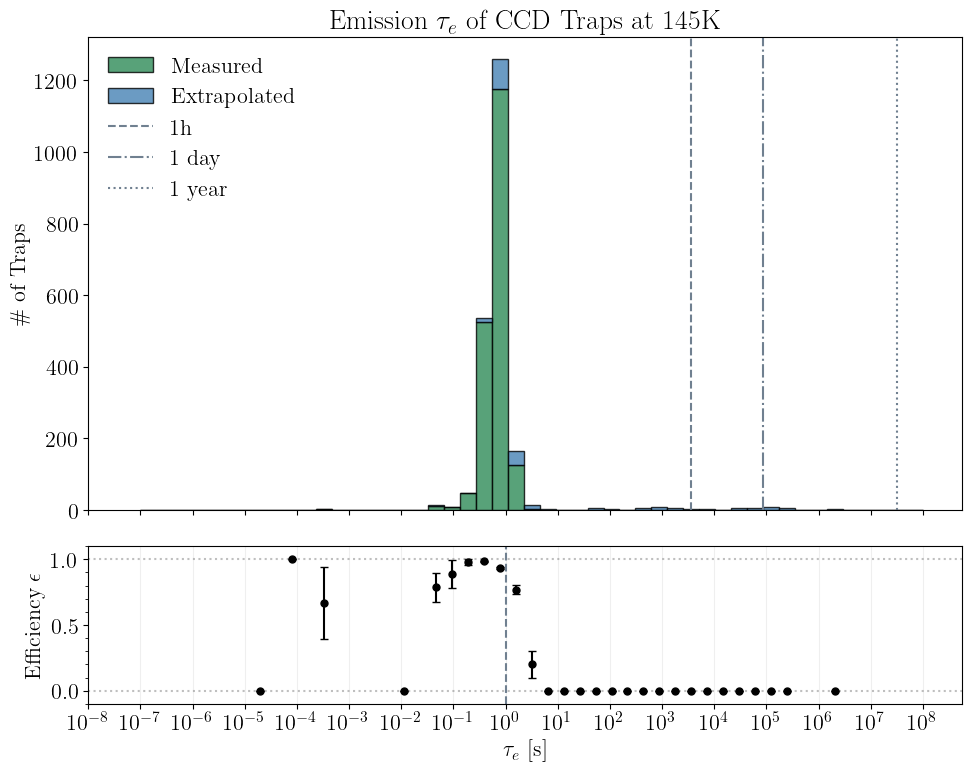

Temperature: 150K | Measured: 2007 | Extrapolated: 112


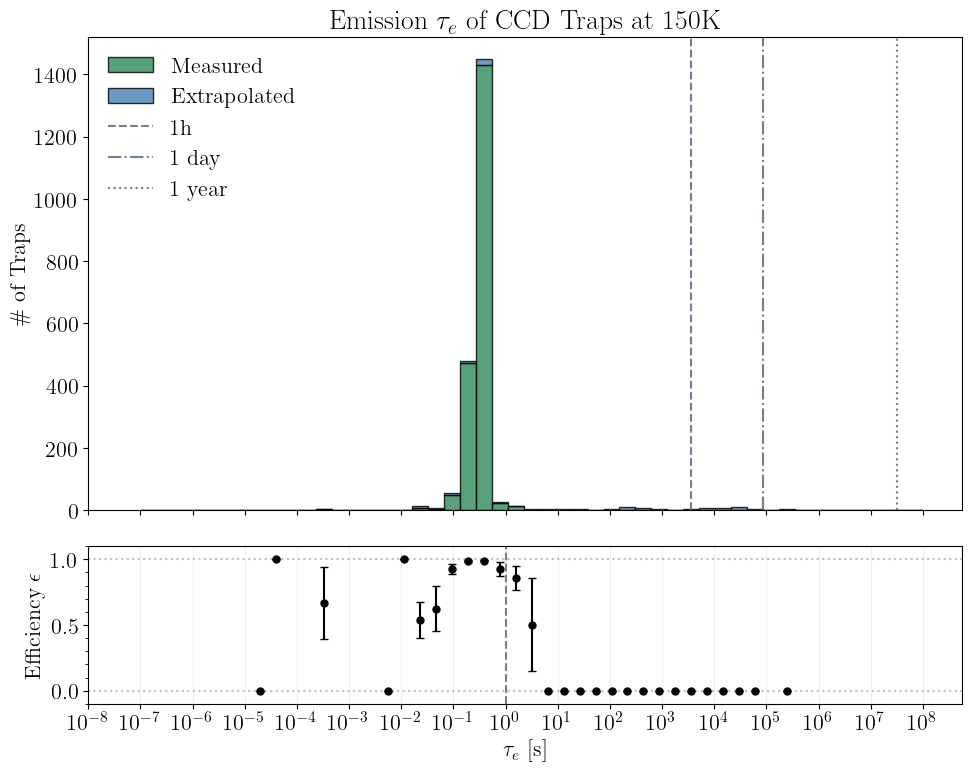

Temperature: 155K | Measured: 1972 | Extrapolated: 147


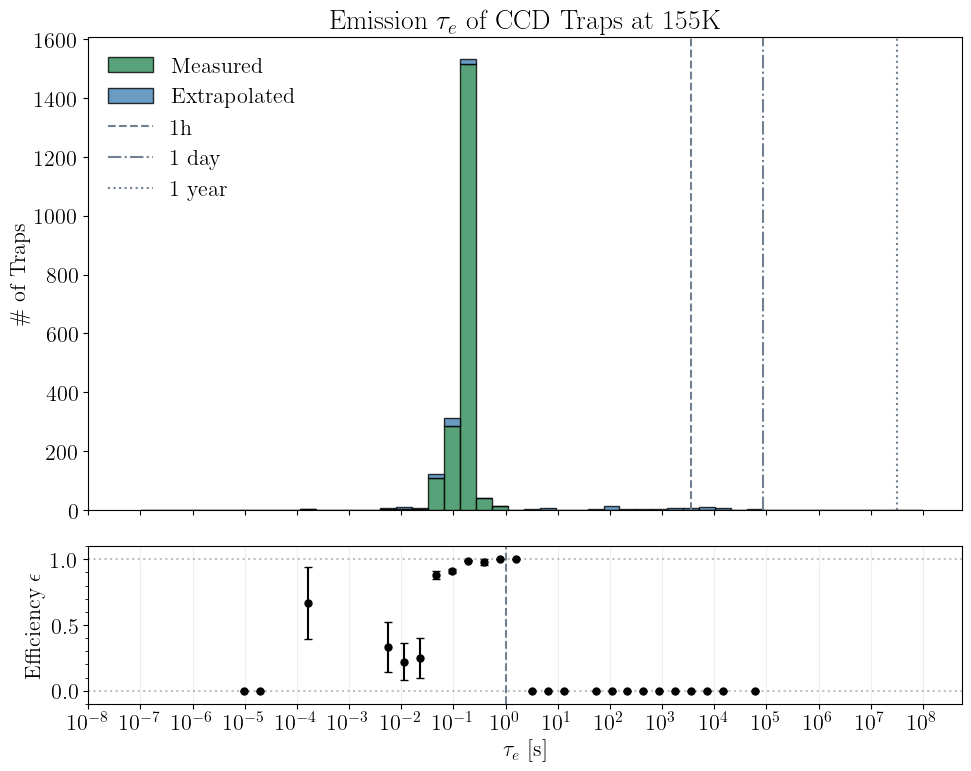

Temperature: 160K | Measured: 1675 | Extrapolated: 444


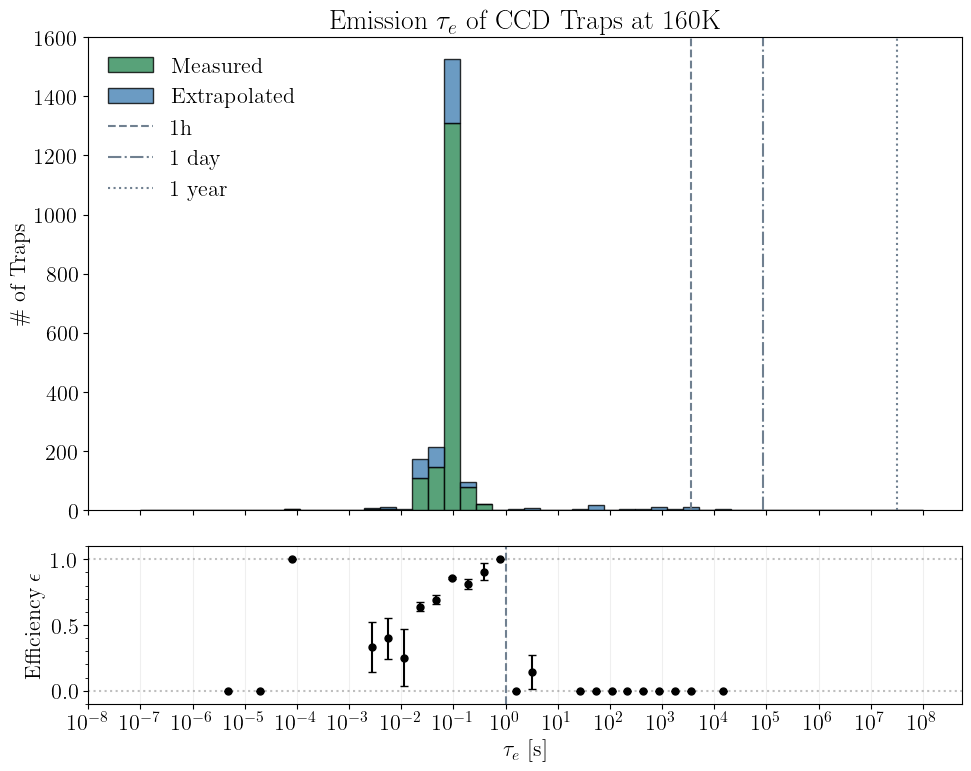

Temperature: 165K | Measured: 1132 | Extrapolated: 987


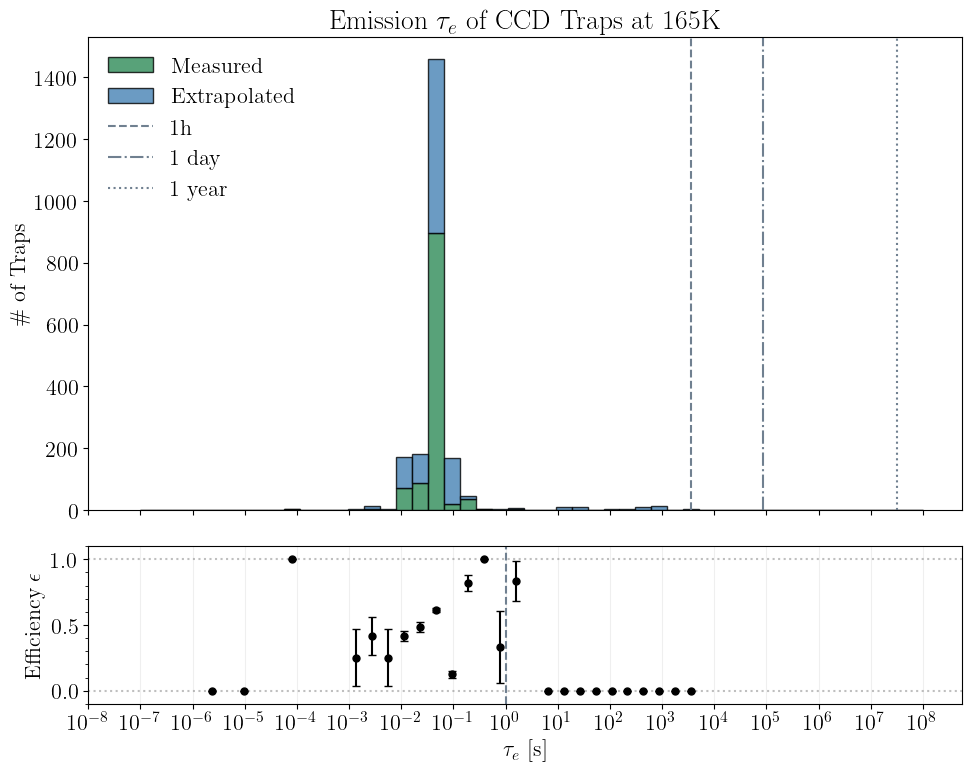

Temperature: 170K | Measured: 730 | Extrapolated: 1389


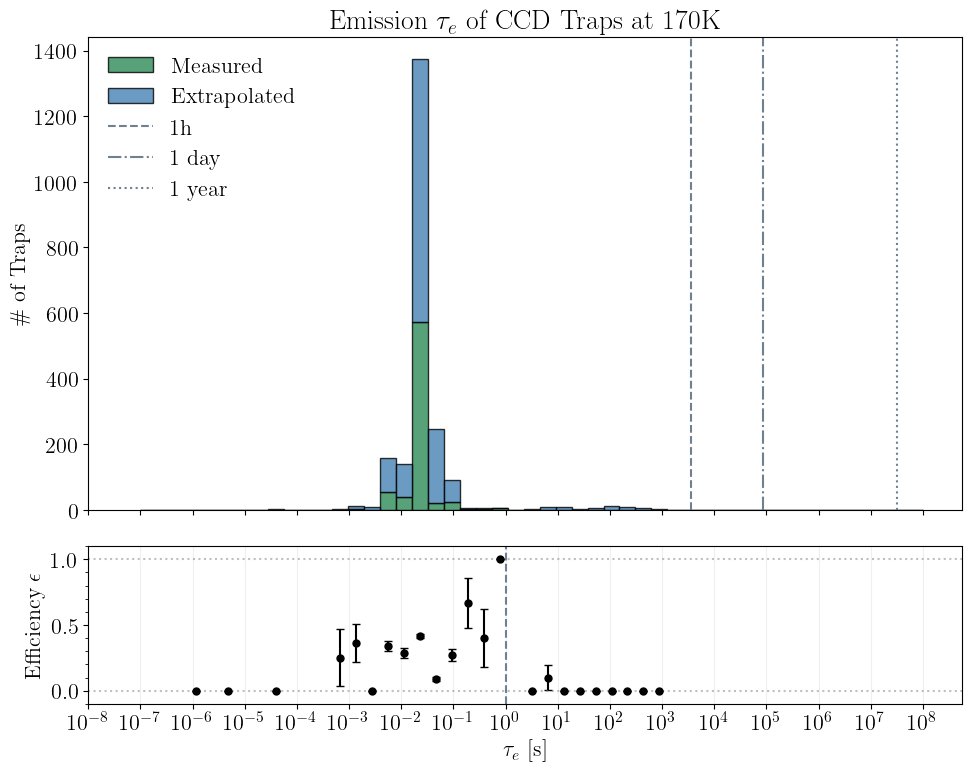

Temperature: 175K | Measured: 530 | Extrapolated: 1589


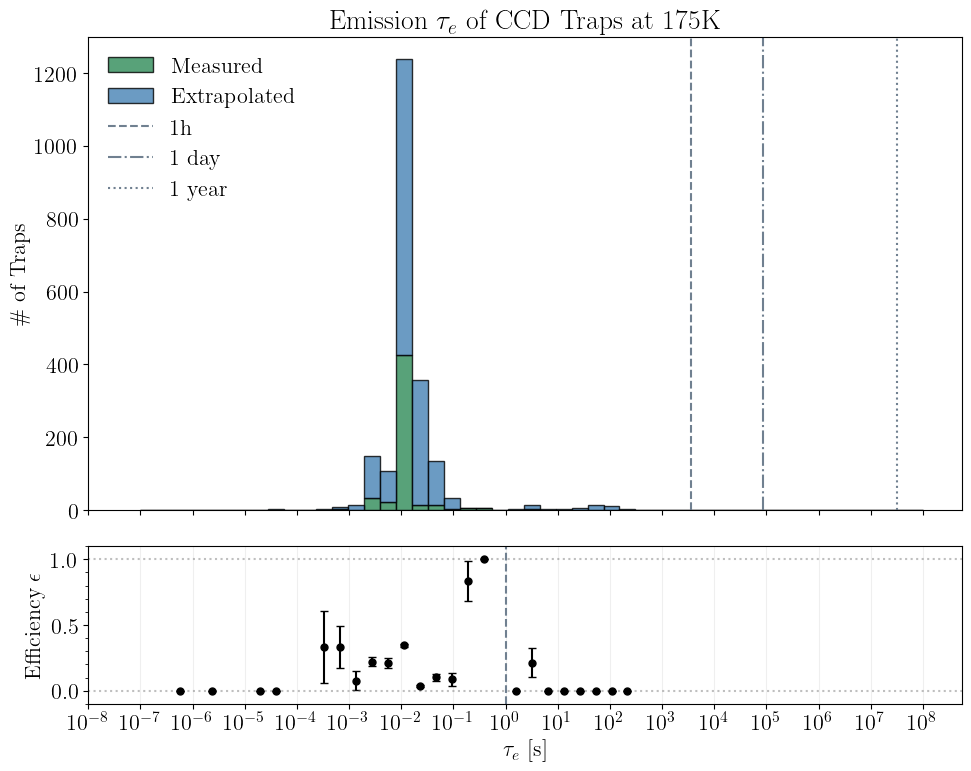

Temperature: 180K | Measured: 399 | Extrapolated: 1720


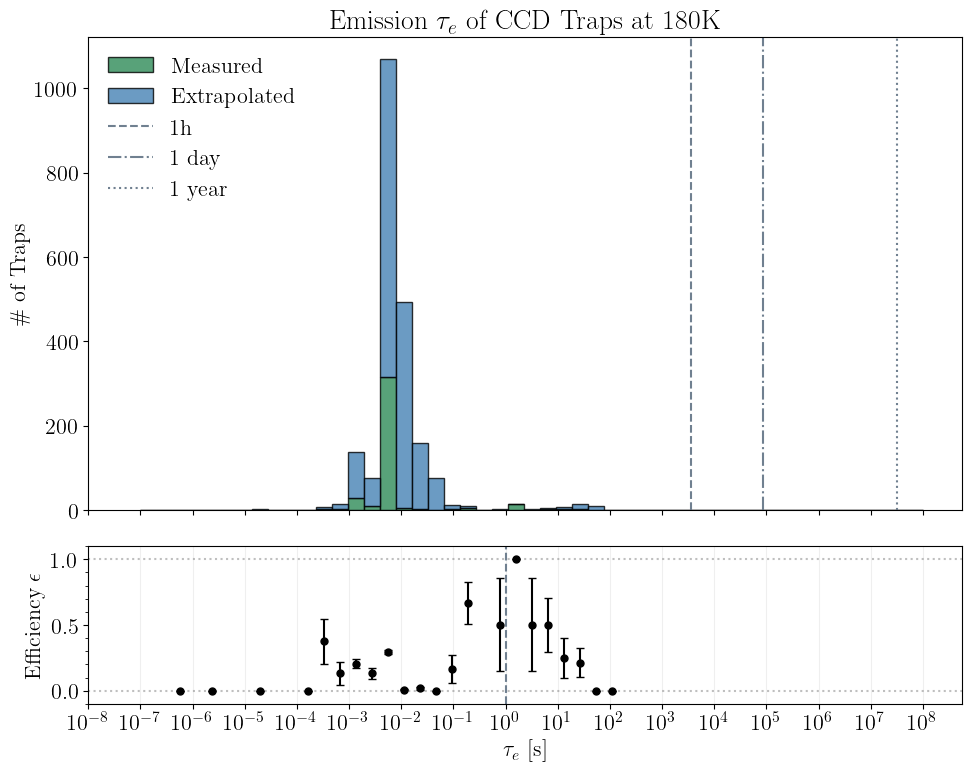

Temperature: 183K | Measured: 367 | Extrapolated: 1752


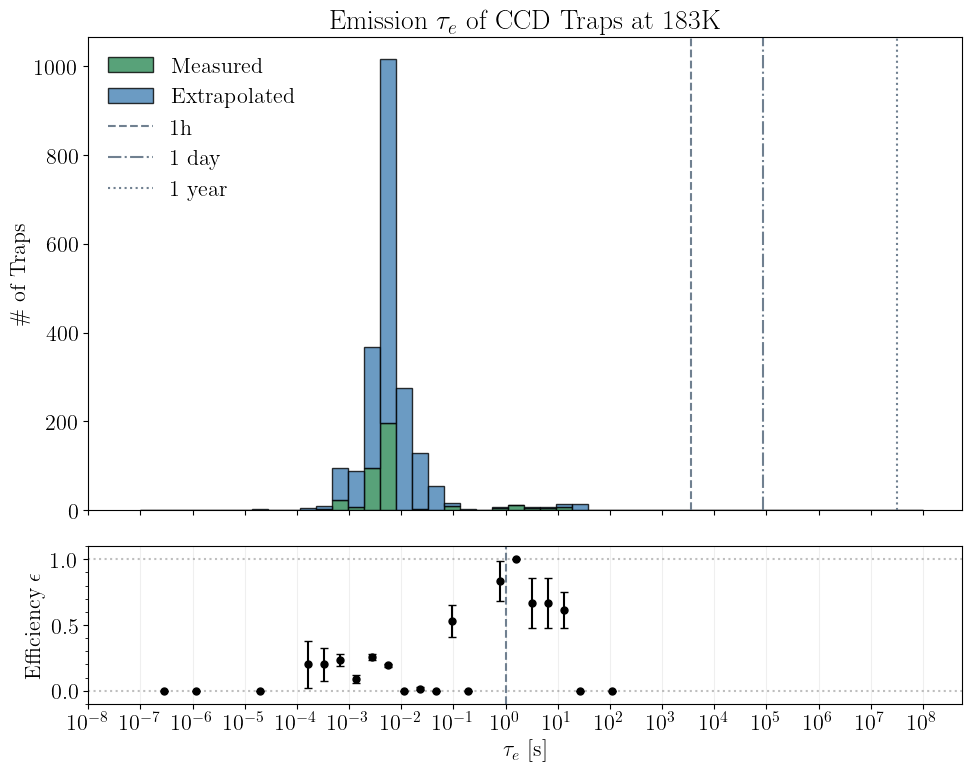

Temperature: 185K | Measured: 357 | Extrapolated: 1762


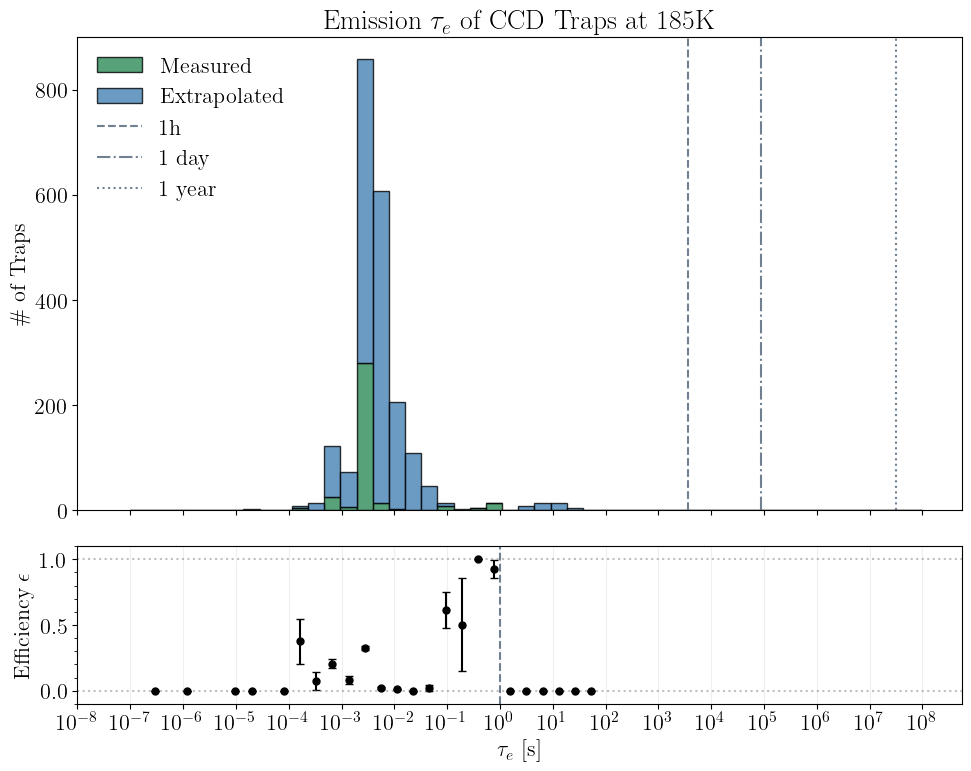

Temperature: 187K | Measured: 352 | Extrapolated: 1767


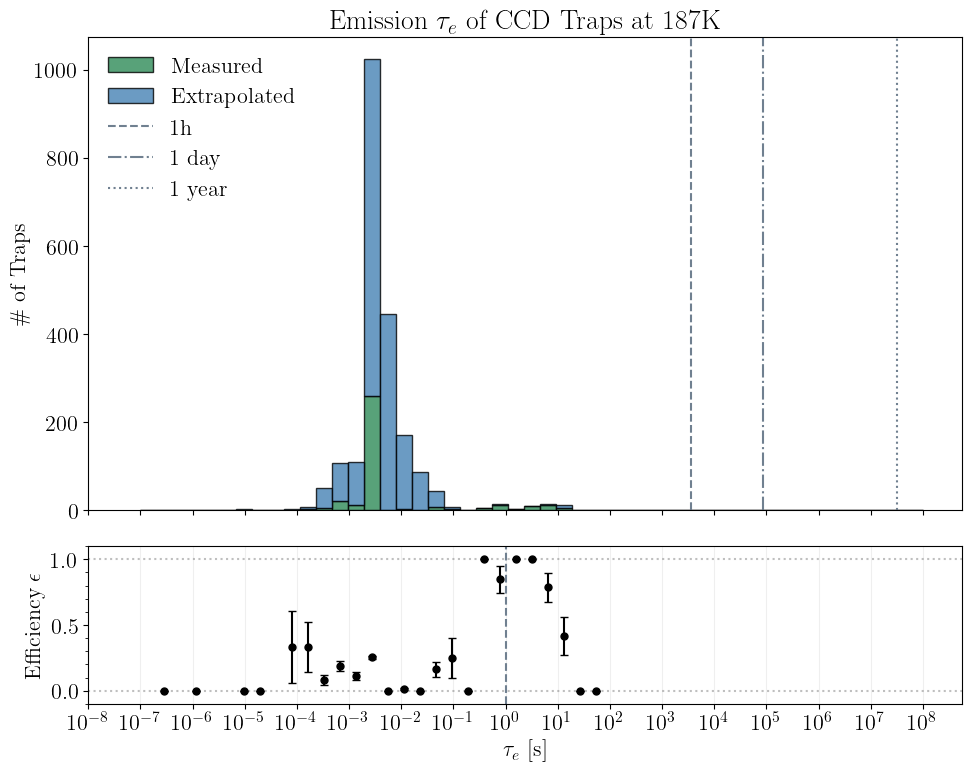

Temperature: 190K | Measured: 328 | Extrapolated: 1791


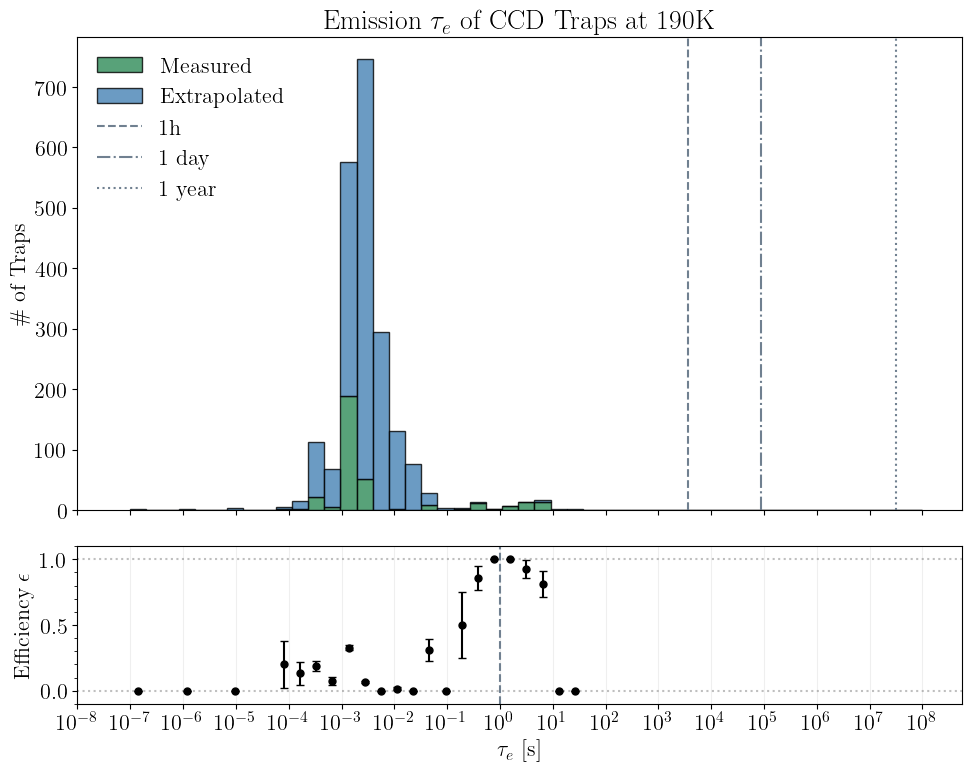

Temperature: 193K | Measured: 302 | Extrapolated: 1817


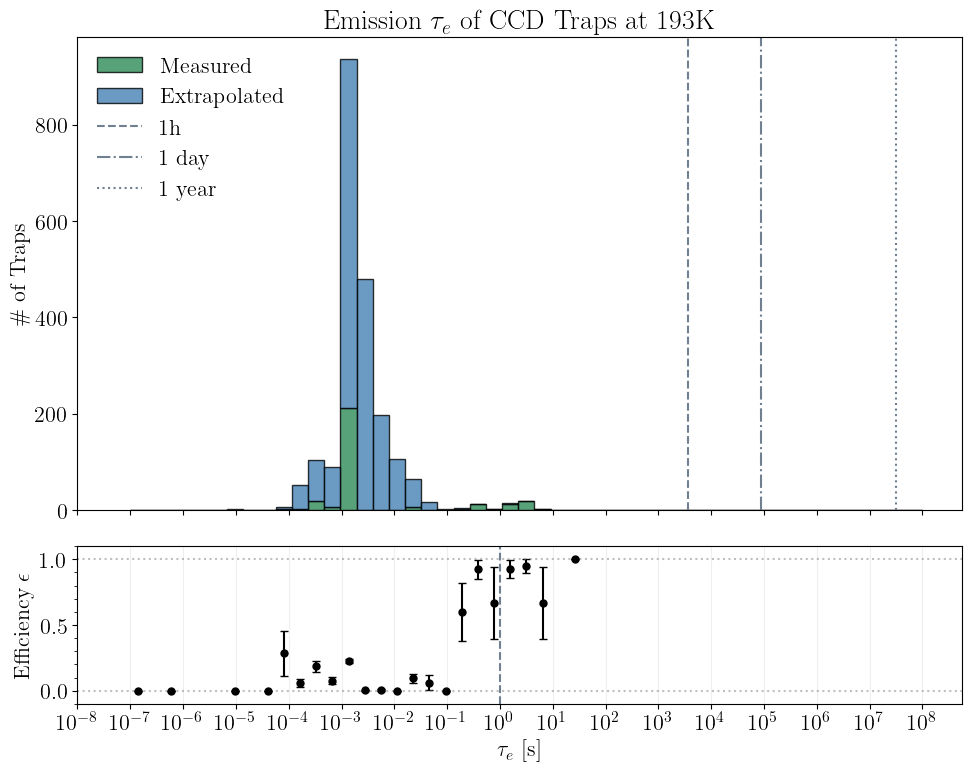

Temperature: 195K | Measured: 300 | Extrapolated: 1819


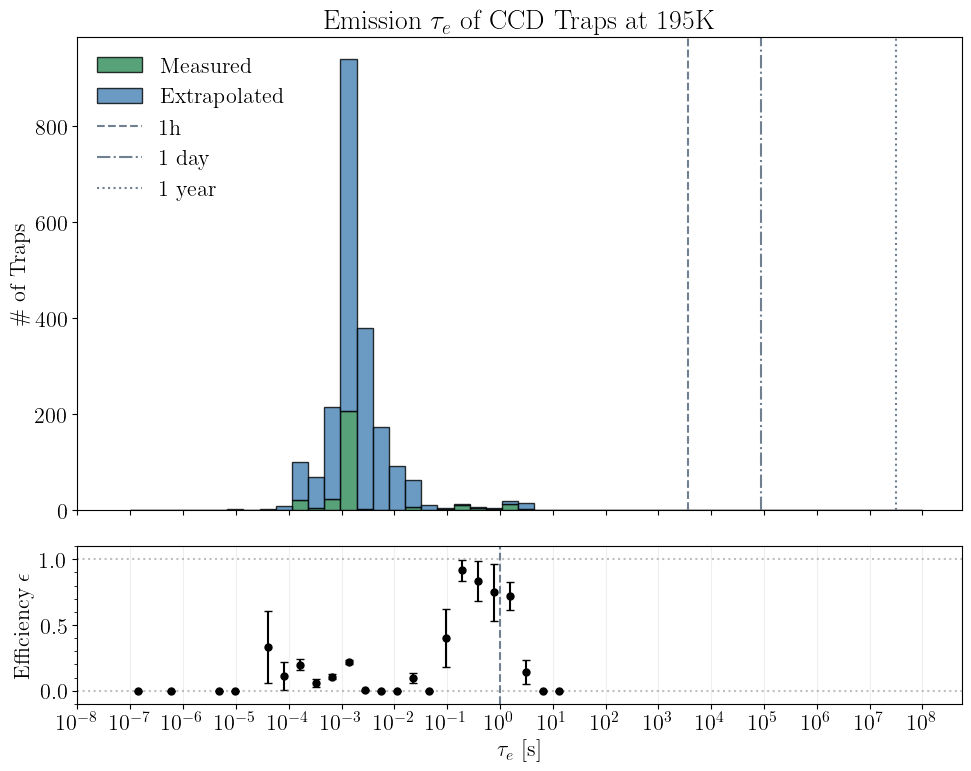

Temperature: 197K | Measured: 288 | Extrapolated: 1831


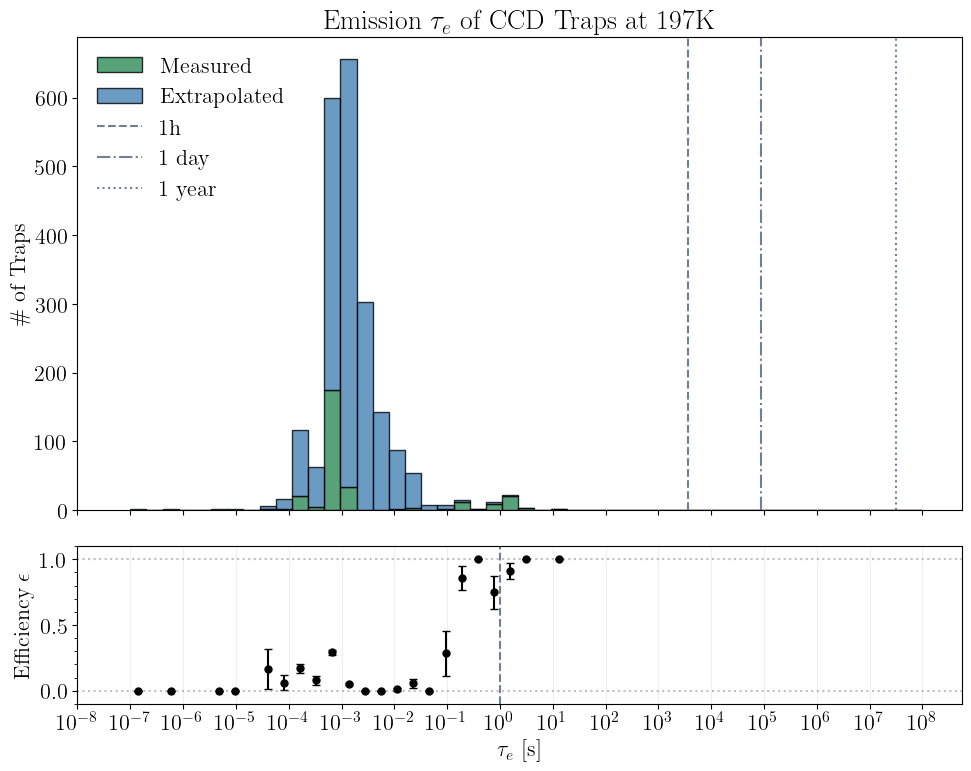

Temperature: 200K | Measured: 283 | Extrapolated: 1836


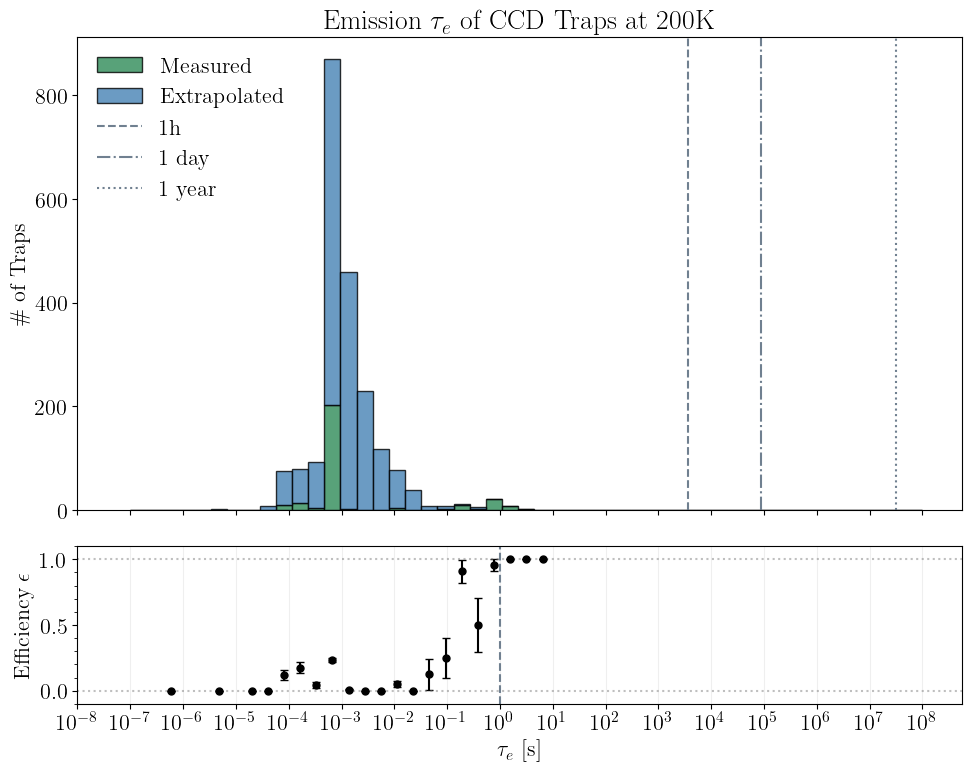

Temperature: 203K | Measured: 250 | Extrapolated: 1869


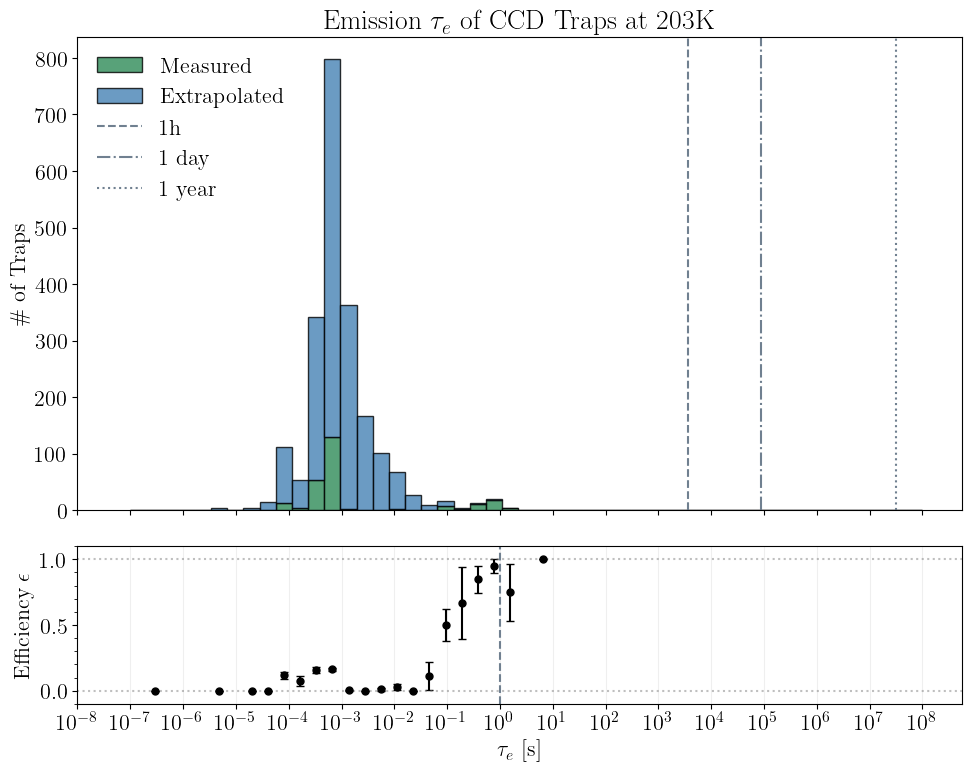

Temperature: 207K | Measured: 217 | Extrapolated: 1902


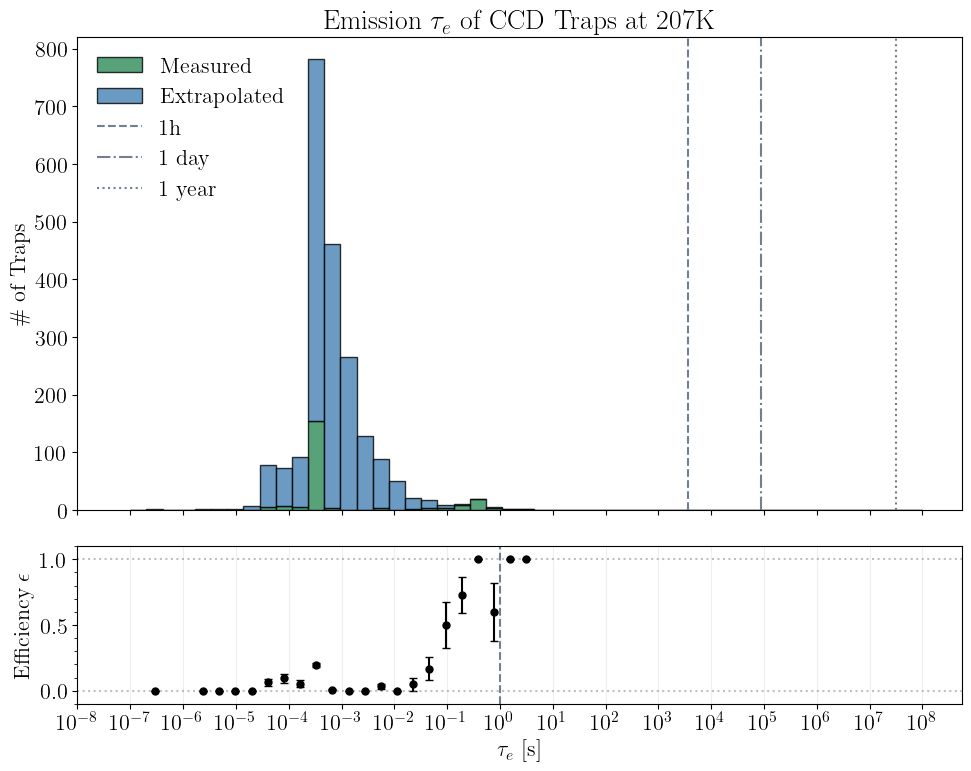

Temperature: 210K | Measured: 245 | Extrapolated: 1874


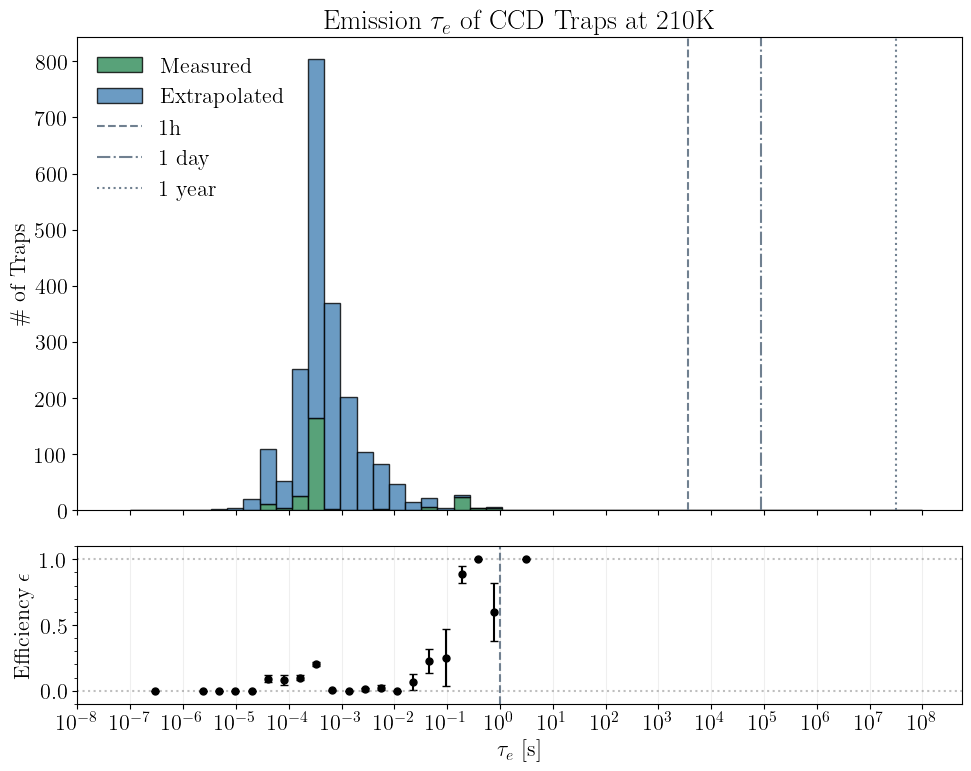

In [316]:
import numpy as np
import matplotlib.pyplot as plt

for t in tau_temperatures.keys():
    measured_taus = tau_temperatures[t]['measured']
    extrapolated_taus = tau_temperatures[t]['extrapolated']
    
    # The 'Truth' or total number of traps is the sum of both lists
    total_taus = measured_taus + extrapolated_taus
    
    if len(total_taus) == 0:
        continue
        
    print(f"Temperature: {t}K | Measured: {len(measured_taus)} | Extrapolated: {len(extrapolated_taus)}")

    # Set up a 2-panel plot (Top for Histogram, Bottom for Efficiency)
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ax_hist = axes[0]
    ax_eff = axes[1]
    
    bins = np.geomspace(1e-7, 1e8, 50)

    # 1. Plot the Standard Histograms (Top Panel)
    # Using stacked=True is often better here so "Measured" sits on top of "Extrapolated" to show the Total
    ax_hist.hist([measured_taus, extrapolated_taus], bins=bins, stacked=True, 
                 color=['seagreen', 'steelblue'], edgecolor='black', alpha=0.8, 
                 label=['Measured', 'Extrapolated'])

    ax_hist.set_title(f"Emission $\\tau_e$ of CCD Traps at {t}K", fontsize=20)
    ax_hist.set_ylabel("\# of Traps", fontsize=16)
    # ax_hist.set_yscale('log') # Often helpful if extrapolated tails are very large
    
    ax_hist.axvline(3600, label='1h', ls='--', color='slategrey')
    ax_hist.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
    ax_hist.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')
    ax_hist.legend(frameon=False, fontsize=16)

    # 2. Calculate the Efficiency (Bottom Panel)
    # Bin the data manually to do the math
    meas_counts, _ = np.histogram(measured_taus, bins=bins)
    tot_counts, _ = np.histogram(total_taus, bins=bins)
    
    # Avoid division by zero warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        efficiency = meas_counts / tot_counts
        
    # Find the geometric centers of the bins for plotting the scatter points
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    # Calculate simple binomial errors for the efficiency (sigma = sqrt(p*(1-p)/N))
    # Where N is total_counts. Set to 0 if total_counts is 0 to avoid warnings
    eff_err = np.zeros_like(efficiency)
    valid = tot_counts > 0
    eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
    # Plot the efficiency points with error bars
    ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
                    fmt='o', color='black', markersize=5, capsize=3)
    
    # Formatting the Efficiency Panel
    ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=small)
    ax_eff.set_ylabel("Efficiency $\\epsilon$", fontsize=small)
    ax_eff.set_xscale('log')
    ax_eff.set_ylim(-0.1, 1.1)
    ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
    ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
    ax_eff.grid(True, which='both', axis='x', alpha=0.2)


    ax_eff.set_xticks(np.logspace(-8,8,17))
    ax.tick_params(axis='x', labelsize=smaller) 
    ax_eff.minorticks_on()

    ax_eff.axvline(1e0,ls='--',color='slategrey')
    

    plt.tight_layout()
    plt.show()
    plt.close()


Total Traps Measured: 15160
Total Traps Extrapolated: 33577


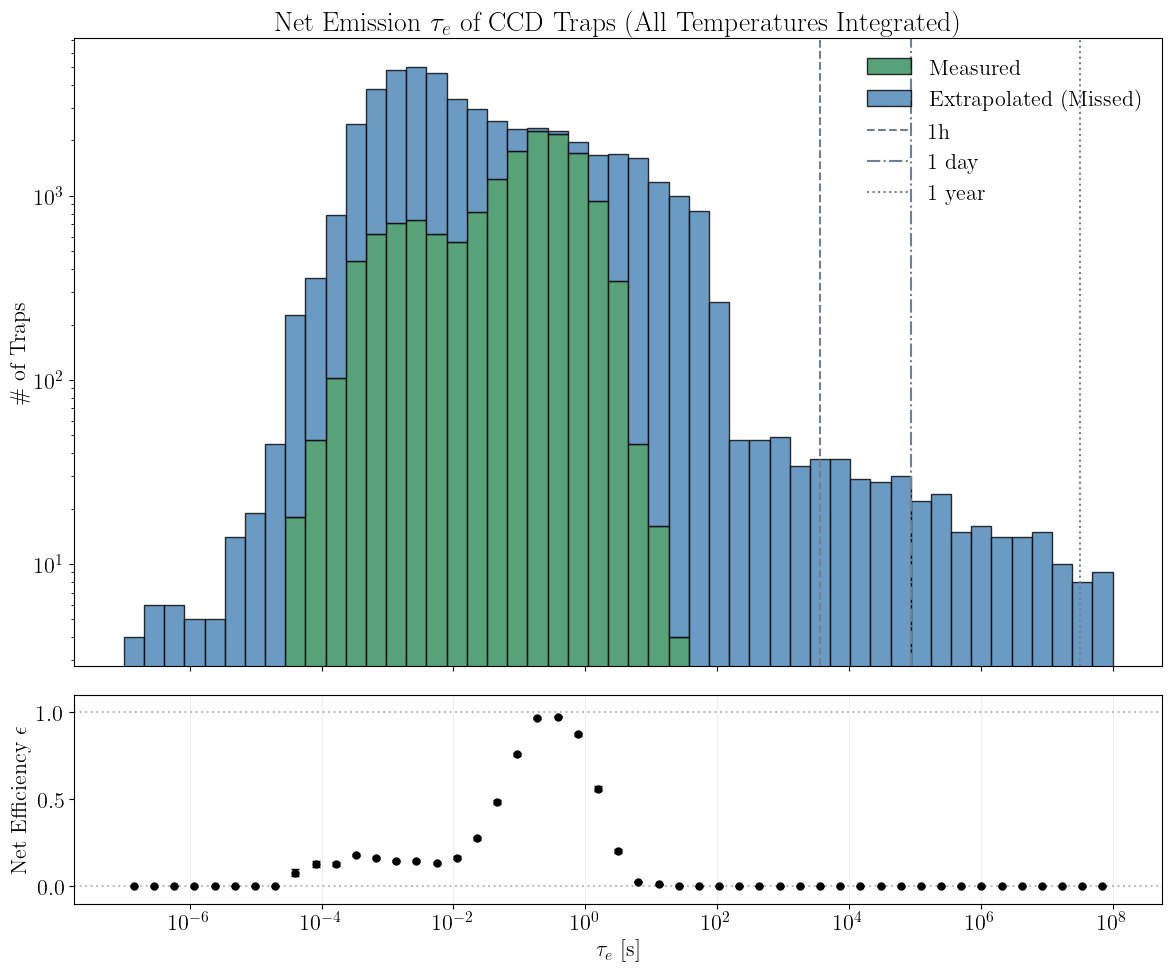

In [317]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Aggregate data across all temperatures
all_measured_taus = []
all_extrapolated_taus = []

for t in tau_temperatures.keys():
    all_measured_taus.extend(tau_temperatures[t]['measured'])
    all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

all_total_taus = all_measured_taus + all_extrapolated_taus

print(f"Total Traps Measured: {len(all_measured_taus)}")
print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

if len(all_total_taus) > 0:
    # 2. Set up the Two-Panel Plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ax_hist = axes[0]
    ax_eff = axes[1]
    
    # bins = np.geomspace(1e-7, 1e8, 75)

    # --- Top Panel: Stacked Histogram ---
    ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
                 color=['seagreen', 'steelblue'], edgecolor='black', alpha=0.8, 
                 label=['Measured', 'Extrapolated (Missed)'])

    ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
    ax_hist.set_ylabel("\\# of Traps", fontsize=16)
    ax_hist.set_yscale('log')
    
    ax_hist.axvline(3600, label='1h', ls='--', color='slategrey')
    ax_hist.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
    ax_hist.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')
    ax_hist.legend(frameon=False, fontsize=16)

    # --- Bottom Panel: Net Efficiency ---
    meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
    tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
    # Safely calculate efficiency
    with np.errstate(divide='ignore', invalid='ignore'):
        efficiency = meas_counts / tot_counts
        
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    # Calculate binomial errors
    eff_err = np.zeros_like(efficiency)
    valid = tot_counts > 0
    eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
    ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
                    fmt='o', color='black', markersize=5, capsize=3)
    
    # Formatting
    ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=16)
    ax_eff.set_ylabel("Net Efficiency $\\epsilon$", fontsize=16)
    ax_eff.set_xscale('log')
    ax_eff.set_ylim(-0.1, 1.1)
    ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
    ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
    ax_eff.grid(True, which='both', axis='x', alpha=0.2)

    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("No data available to plot.")


<>:87: SyntaxWarning: invalid escape sequence '\#'
<>:87: SyntaxWarning: invalid escape sequence '\#'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/3085144936.py:87: SyntaxWarning: invalid escape sequence '\#'
  plt.ylabel('Estimated \# of Traps', fontsize=14)


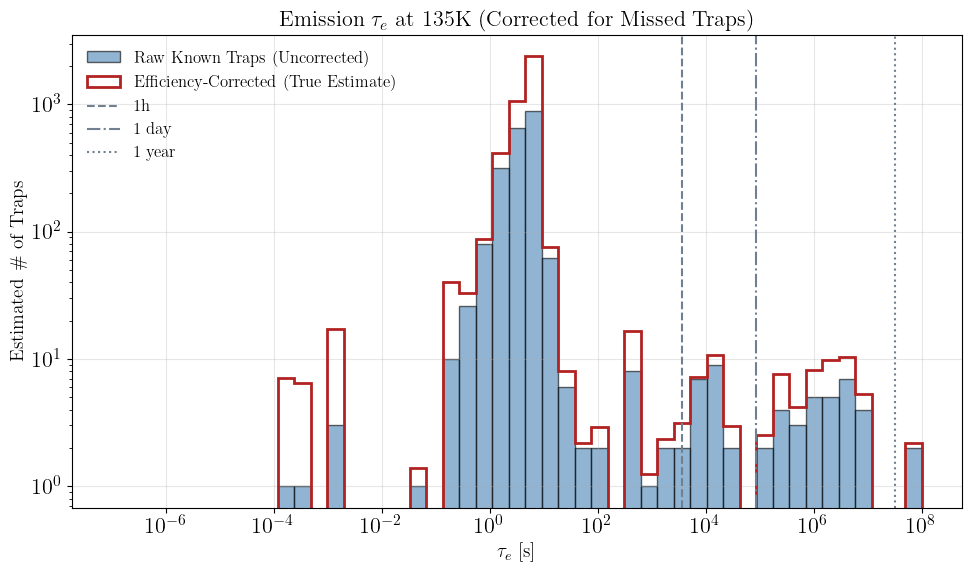

In [320]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ====================================================================
# 1. Build the Universal "Master Efficiency Curve"
# ====================================================================
all_measured = []
all_extrapolated = []
for t in tau_temperatures.keys():
    all_measured.extend(tau_temperatures[t]['measured'])
    all_extrapolated.extend(tau_temperatures[t]['extrapolated'])

all_total = all_measured + all_extrapolated
# bins = np.geomspace(1e-7, 1e8, 75)

meas_counts, _ = np.histogram(all_measured, bins=bins)
tot_counts, _ = np.histogram(all_total, bins=bins)

# Calculate efficiency safely
with np.errstate(divide='ignore', invalid='ignore'):
    master_efficiency = meas_counts / tot_counts
    
bin_centers = np.sqrt(bins[:-1] * bins[1:])

# Create a safe trust window (only trust regions with > 5% efficiency)
trust_mask = (master_efficiency > 0.05) & (~np.isnan(master_efficiency))

# Create a continuous interpolation function for the efficiency
master_eff_func = interp1d(
    bin_centers[trust_mask], 
    master_efficiency[trust_mask], 
    kind='linear', 
    bounds_error=False, 
    fill_value=np.nan
)

# ====================================================================
# 2. Weight every characterized trap based on where it was observed
# ====================================================================
target_temp = 135.0

tau_target_list = []
weights_list = []

for d, data in enumerate(energy_crossSections):
    cs = data[0]
    energy = data[1]
    avgtemp = data[4]  # The temperature where this trap was best measured
    
    # Calculate the tau of this trap AT THE TEMPERATURE IT WAS MEASURED
    logtau_obs = log_energy_cross_section(avgtemp, energy, np.log(cs))
    tau_obs = np.exp(logtau_obs)
    
    # Get the efficiency for this tau from our master curve
    trap_eff = master_eff_func(tau_obs)
    
    # Skip traps that fell outside our 5% reliable interpolation window
    if np.isnan(trap_eff) or trap_eff <= 0:
        continue 
        
    trap_weight = 1.0 / trap_eff
    
    # Now, calculate the tau of this trap at our TARGET extrapolated temperature
    logtau_target = log_energy_cross_section(target_temp, energy, np.log(cs))
    tau_target = np.exp(logtau_target)
    
    tau_target_list.append(tau_target)
    weights_list.append(trap_weight)

# ====================================================================
# 3. Plot the final Corrected Histogram!
# ====================================================================
plt.figure(figsize=(10, 6))

# Plot the Unweighted (Raw Known Traps)
plt.hist(tau_target_list, bins=bins, color='steelblue', edgecolor='black', 
         alpha=0.6, label='Raw Known Traps (Uncorrected)')

# Plot the Weighted (True Extrapolated Estimate)
plt.hist(tau_target_list, bins=bins, weights=weights_list, 
         edgecolor='firebrick', lw=2, histtype='step', 
         label='Efficiency-Corrected (True Estimate)')

plt.title(f"Emission $\\tau_e$ at {int(target_temp)}K (Corrected for Missed Traps)", fontsize=16)
plt.xlabel('$\\tau_e$ [s]', fontsize=14)
plt.ylabel('Estimated \# of Traps', fontsize=14)
plt.xscale('log')
plt.yscale('log')

plt.axvline(3600, label='1h', ls='--', color='slategrey')
plt.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
plt.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')

plt.legend(frameon=False, fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


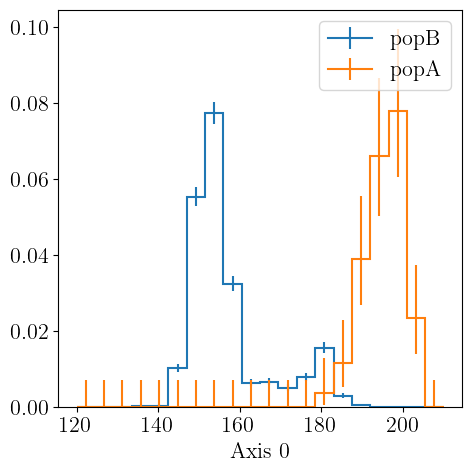

In [308]:
hA = hist.new.Reg(20,120,210).Double()
hA.fill(avg_A)

hB = hist.new.Reg(20,120,210).Double()
hB.fill(avg_B)

plt.figure()
ax = plt.gca()
hB.plot1d(ax=ax,label='popB',density=True)
hA.plot1d(ax=ax,label='popA',density=True)
plt.legend()
plt.show()
plt.close()

<>:75: SyntaxWarning: invalid escape sequence '\l'
<>:75: SyntaxWarning: invalid escape sequence '\l'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/1666399823.py:75: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\ln(\sigma)$ (Cross-Section)')


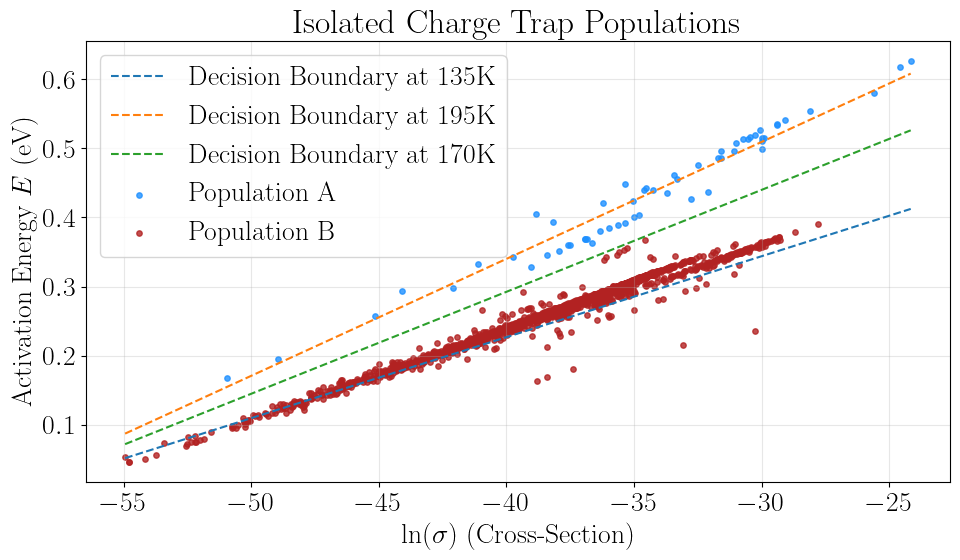

In [123]:
import numpy as np
import matplotlib.pyplot as plt

energies = []
log_cross_sections = []

# 1. Extract valid data from your nested dictionary
goodQuads = [0, 1, 2, 3] # Adjust if needed
for q in goodQuads:
    dpkeys = list(fit_dipole_spectra[q].keys())
    for dp in dpkeys:
        if type(dp) != tuple:
            continue
            
        testdp = fit_dipole_spectra[q][dp]
        
        # Only grab traps that passed your fit criteria
        if testdp.get('WellBehavedTrap') and testdp.get('GoodEnergyFit'):
            fit_info = testdp['EnergyFitInfo']
            
            e = fit_info['BestFitEnergy']
            cs = fit_info['BestFitCrossSection']
            
            energies.append(e)
            log_cross_sections.append(np.log(cs))

energies = np.array(energies)
log_cross_sections = np.array(log_cross_sections)

# # 2. Define a linear decision boundary
# # You will need to visually tweak the slope (m) and intercept (b) 
# # to perfectly slice between your two populations
# m = 0.014  # Example slope 
# b = 0.85 # Example intercept



# 3. Plotting the isolated populations
plt.figure(figsize=(10, 6))

# Plot Population 1 (e.g., the steeper/upper line)

# Draw the decision boundary for visual confirmation
x_vals = np.linspace(min(log_cross_sections), max(log_cross_sections), 100)
# plt.plot(x_vals, m * x_vals + b, color='black', linestyle='--', label='Decision Boundary')

kb = 8.6717333262e-5
for T in [135,195,170]:#[125,135,145,165,175,185,195]:
    m =  (kb*T)
    tau_test = 1
    # tau_test = 0.00002
    # np.log(0.00002)
    b = m * (np.log(tau_test) - (-68.267 ) + 2 * np.log(m))
    plt.plot(x_vals, m * x_vals + b, linestyle='--', label=f'Decision Boundary at {T}K')

# Create a boolean mask separating the two populations
pop1_mask = energies > (m * log_cross_sections + b)
pop2_mask = ~pop1_mask

plt.scatter(log_cross_sections[pop1_mask], energies[pop1_mask],
            color='dodgerblue', label='Population A', s=15, alpha=0.8)

# Plot Population 2 (e.g., the shallower/lower line)
plt.scatter(log_cross_sections[pop2_mask], energies[pop2_mask],
            color='firebrick', label='Population B', s=15, alpha=0.8)



# plt.plot(x_vals, m * x_vals + b, color='black', linestyle='--', label='Decision Boundary')


# plt.plot(x_vals, m * x_vals + b, color='black', linestyle='--', label='Decision Boundary')

plt.ylabel('Activation Energy $E$ (eV)')
plt.xlabel('$\ln(\sigma)$ (Cross-Section)')
plt.title('Isolated Charge Trap Populations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
kb = 8.6717333262e-5 #eV / K
m/kb

161.44407897901624

In [69]:
m

0.014

-10.819778284410283

<>:73: SyntaxWarning: invalid escape sequence '\l'
<>:73: SyntaxWarning: invalid escape sequence '\l'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/295190996.py:73: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel('$\ln(\sigma)$ (Cross-Section)')


Systematic analysis suggests there are 3 distinct populations.
Overriding BIC: Forcing exactly 2 populations based on temperature bimodality.


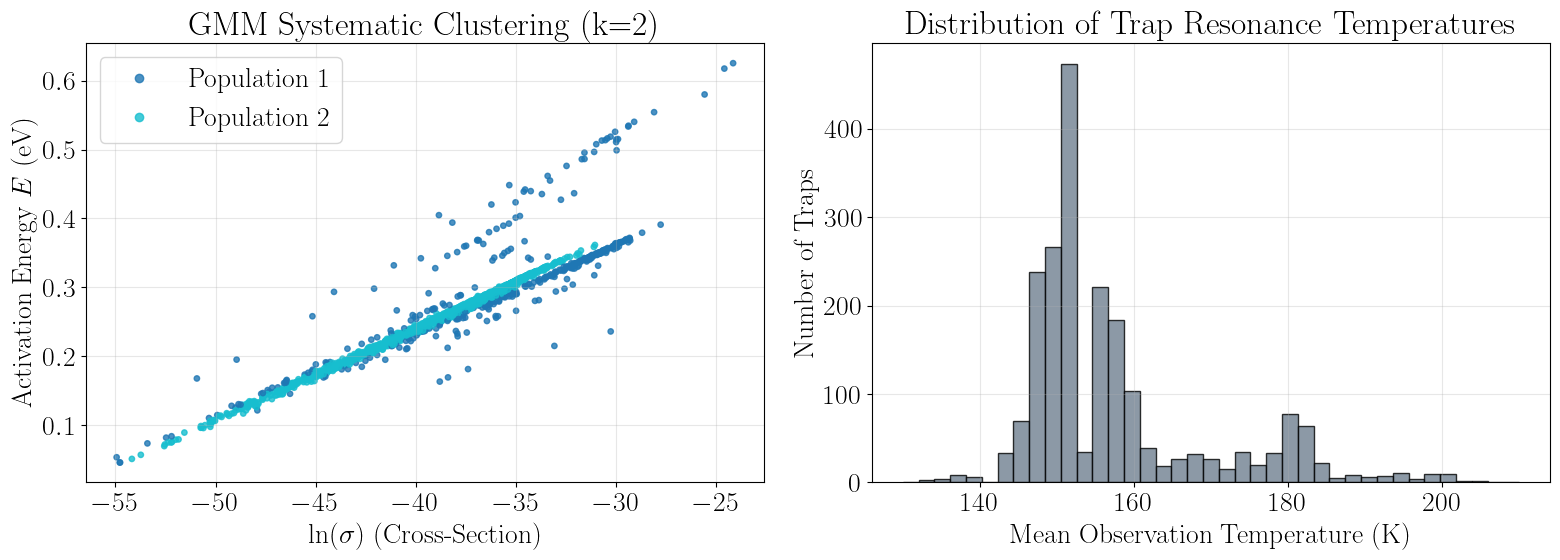

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. Extract Data
energies = []
log_cross_sections = []
mean_temps = []

# Assuming fit_dipole_spectra is loaded in your environment
goodQuads = [0, 1, 2, 3] 
for q in goodQuads:
    dpkeys = list(fit_dipole_spectra[q].keys())
    for dp in dpkeys:
        if type(dp) != tuple: continue
        
        testdp = fit_dipole_spectra[q][dp]
        
        if testdp.get('WellBehavedTrap') and testdp.get('GoodEnergyFit'):
            fit_info = testdp['EnergyFitInfo']
            
            energies.append(fit_info['BestFitEnergy'])
            log_cross_sections.append(np.log(fit_info['BestFitCrossSection']))
            # Capture the mean temperature this trap was successfully fit at
            mean_temps.append(np.mean(fit_info['temperatures']))

energies = np.array(energies)
log_cross_sections = np.array(log_cross_sections)
mean_temps = np.array(mean_temps)

# Stack our 2D data for the Machine Learning model
X = np.column_stack((log_cross_sections, energies))

# 2. Find optimal number of clusters using BIC
max_clusters = 3
bics = []
models = []

for k in range(1, max_clusters + 1):
    # covariance_type='full' is crucial here! It allows the clusters to stretch into lines.
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X)
    bics.append(gmm.bic(X))
    models.append(gmm)

# The optimal model is the one with the lowest BIC score
optimal_k_idx = np.argmin(bics)
optimal_k = optimal_k_idx + 1
best_gmm = models[optimal_k_idx]

# Let the model systematically assign each trap to a population
labels = best_gmm.predict(X)
print(f"Systematic analysis suggests there are {optimal_k} distinct populations.")


# # 2. Force exactly 2 clusters based on physical temperature peaks
optimal_k = 2

# Fit the GMM with exactly 2 components
best_gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
labels = best_gmm.fit_predict(X)

print("Overriding BIC: Forcing exactly 2 populations based on temperature bimodality.")



# 3. Plotting the Results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The Machine Learning Clustering
scatter = axes[0].scatter(log_cross_sections,energies, c=labels, cmap='tab10', s=15, alpha=0.8)
axes[0].set_ylabel('Activation Energy $E$ (eV)')
axes[0].set_xlabel('$\ln(\sigma)$ (Cross-Section)')
axes[0].set_title(f'GMM Systematic Clustering (k={optimal_k})')
axes[0].grid(True, alpha=0.3)

# Add a legend mapping colors to the populations
handles, _ = scatter.legend_elements()
axes[0].legend(handles, [f"Population {i+1}" for i in range(optimal_k)])

# Plot B: The Physics Sanity Check
axes[1].hist(mean_temps, np.linspace(130,210,40), color='slategray', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Mean Observation Temperature (K)')
axes[1].set_ylabel('Number of Traps')
axes[1].set_title('Distribution of Trap Resonance Temperatures')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/32428254.py:7: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_ylabel('$\ln(\sigma)$ (Cross-Section)')
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21421/32428254.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10')


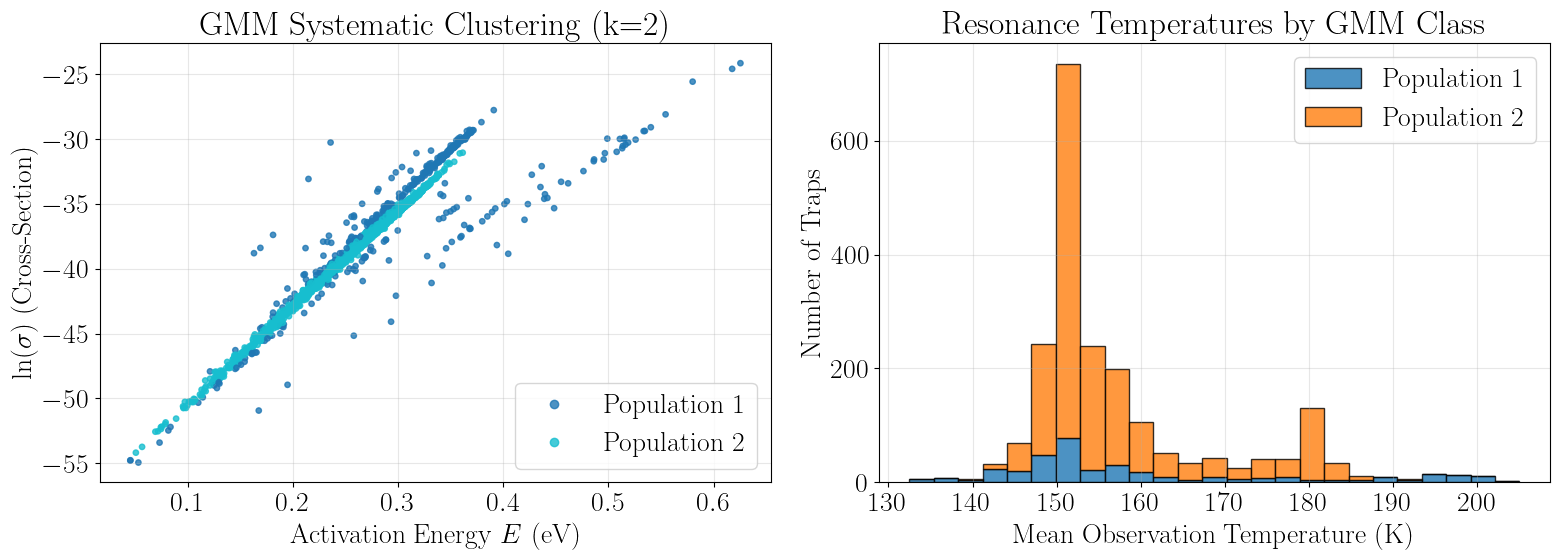

In [ ]:
# 3. Plotting the Results with Colored Histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: The Machine Learning Clustering ---
scatter = axes[0].scatter(energies, log_cross_sections, c=labels, cmap='tab10', s=15, alpha=0.8)
axes[0].set_xlabel('Activation Energy $E$ (eV)')
axes[0].set_ylabel('$\ln(\sigma)$ (Cross-Section)')
axes[0].set_title(f'GMM Systematic Clustering (k={optimal_k})')
axes[0].grid(True, alpha=0.3)

# Add a legend mapping colors to the populations
handles, _ = scatter.legend_elements()
axes[0].legend(handles, [f"Population {i+1}" for i in range(optimal_k)])


# --- Plot B: The Physics Sanity Check (Colored by Population) ---
# Group the temperatures by their GMM label
temp_groups = [mean_temps[labels == i] for i in range(optimal_k)]

# Extract the exact colors used in the scatter plot so they match
import matplotlib.cm as cm
cmap = cm.get_cmap('tab10')
colorlist = [cmap(i) for i in range(optimal_k)]

# Plot as a stacked histogram
axes[1].hist(temp_groups, bins=25, stacked=True, color=colorlist, edgecolor='black', alpha=0.8, 
             label=[f"Population {i+1}" for i in range(optimal_k)])

axes[1].set_xlabel('Mean Observation Temperature (K)')
axes[1].set_ylabel('Number of Traps')
axes[1].set_title('Resonance Temperatures by GMM Class')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
